# Unsupervised Learning: Trade & Ahead

## Problem Statement

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximise earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones which exhibit minimum correlation. This will help investors better analyze stocks across different market segments and help protect against risks that could make the portfolio vulnerable to losses.


### Objective

Trade&Ahead is a financial consultancy firm who provide their customers with personalized investment strategies. They have hired you as a Data Scientist and provided you with data comprising stock price and some financial indicators for a few companies listed under the New York Stock Exchange. They have assigned you the tasks of analyzing the data, grouping the stocks based on the attributes provided, and sharing insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Company: Name of the company
- GICS Sector: The specific economic sector assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity (shareholders' equity is equal to a company's assets minus its debt)
- Cash Ratio: The ratio of a  company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: Ratio of the company's current stock price to the earnings per share
- P/B Ratio: Ratio of the company's stock price per share by its book value per share (book value of a company is the net difference between that company's total assets and total liabilities)

## Importing necessary libraries and data

In [ ]:
!pip install yellowbrick -q --user
!pip install --upgrade -q jinja2

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# dimentionality reduction
from sklearn.decomposition import PCA

# for visualizing high-dimensional data
from sklearn.manifold import TSNE

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# to read the csv file
df_stock = pd.read_csv('/content/drive/MyDrive/Python Course/Module 6/Project /stock_data.csv')

In [ ]:
df = df_stock.copy()

## Data Overview

In [ ]:
# returns the first 5 rows in the dataset.
df.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810


In [ ]:
# returns the last 5 rows in the dataset.
df.tail()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
335,YHOO,Yahoo Inc.,Information Technology,Internet Software & Services,33.259998,14.887727,1.845149,15,459,-1032187000,-4359082000,-4.64,939457327.6,28.976191,6.261775
336,YUM,Yum! Brands Inc,Consumer Discretionary,Restaurants,52.516175,-8.698917,1.478877,142,27,159000000,1293000000,2.97,435353535.4,17.682214,-3.838260
337,ZBH,Zimmer Biomet Holdings,Health Care,Health Care Equipment,102.589996,9.347683,1.404206,1,100,376000000,147000000,0.78,188461538.5,131.525636,-23.884449
338,ZION,Zions Bancorp,Financials,Regional Banks,27.299999,-1.158588,1.468176,4,99,-43623000,309471000,1.20,257892500.0,22.749999,-0.063096
339,ZTS,Zoetis,Health Care,Pharmaceuticals,47.919998,16.678836,1.610285,32,65,272000000,339000000,0.68,498529411.8,70.470585,1.723068


In [ ]:
# checks the number of rows and columns in the data
df.shape

(340, 15)

In [ ]:
# checks the datatype of each column, the total rows and columns, and the memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticker Symbol                 340 non-null    object 
 1   Security                      340 non-null    object 
 2   GICS Sector                   340 non-null    object 
 3   GICS Sub Industry             340 non-null    object 
 4   Current Price                 340 non-null    float64
 5   Price Change                  340 non-null    float64
 6   Volatility                    340 non-null    float64
 7   ROE                           340 non-null    int64  
 8   Cash Ratio                    340 non-null    int64  
 9   Net Cash Flow                 340 non-null    int64  
 10  Net Income                    340 non-null    int64  
 11  Earnings Per Share            340 non-null    float64
 12  Estimated Shares Outstanding  340 non-null    float64
 13  P/E R

In [ ]:
# checks the statistical summary of both numerical and categorical variables
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ticker Symbol,340,340,ZTS,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Security,340,340,Zoetis,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GICS Sector,340,11,Industrials,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GICS Sub Industry,340,104,Oil & Gas Exploration & Production,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Current Price,340.0,NaN,NaN,NaN,80.862345,98.055086,4.5,38.555,59.705,92.880001,1274.949951
Price Change,340.0,NaN,NaN,NaN,4.078194,12.006338,-47.129693,-0.939484,4.819505,10.695493,55.051683
Volatility,340.0,NaN,NaN,NaN,1.525976,0.591798,0.733163,1.134878,1.385593,1.695549,4.580042
ROE,340.0,NaN,NaN,NaN,39.597059,96.547538,1.0,9.75,15.0,27.0,917.0
Cash Ratio,340.0,NaN,NaN,NaN,70.023529,90.421331,0.0,18.0,47.0,99.0,958.0
Net Cash Flow,340.0,NaN,NaN,NaN,55537620.588235,1946365312.175789,-11208000000.0,-193906500.0,2098000.0,169810750.0,20764000000.0


In [ ]:
# checks for duplicates in the data and sums them
df.duplicated().sum()

np.int64(0)

In [ ]:
# checks the total number of missing values in each column
print(df.isnull().sum())
# checks total number of missing values in the data
print(df.isnull().sum().sum())

Ticker Symbol                   0
Security                        0
GICS Sector                     0
GICS Sub Industry               0
Current Price                   0
Price Change                    0
Volatility                      0
ROE                             0
Cash Ratio                      0
Net Cash Flow                   0
Net Income                      0
Earnings Per Share              0
Estimated Shares Outstanding    0
P/E Ratio                       0
P/B Ratio                       0
dtype: int64
0


**Observations**:

* The dataset contains 340 observations and 15 columns.

* The 15 columns include 11 numerical (current price, price change, volatility, ROE, cash ratio, net cash flow, net income, earnings per share, estimated shares outstanding, P/E ratio and P/B ratio), 4 categorical (Security, GICS sector, GICS sub industry and ticker symbol).

* There are no missing values in the dataset.

* There are no duplicate data or rows in the dataset.

* There are no issues with the data types of each column.

* There are 11 GICS sectors in the dataset with 'Industrials' having the highest number.

* There are 104 GICS sub industries with 'Oil & Gas Exploration & Production' representing the most.

* The current price ranges from 4.5 to 1274.95 with a mean value of 80.86.

* The value for the price change ranges from -47.13 to 55.05 with a mean value of 4.078.

* The volatilty, which reflects the standard deviation of the stock price ranges from 0.733 to 4.58 with a mean value of 1.52.

* The ROE ranges from 1.0 to 917.0 with a mean value of 39.59.

* The cash ratio ranges from 0 to 958.0 with a mean value of 70.02.

* The net cash flow ranges from -11208000000.0 to 24442000000.0 with a mean value of 55537620.59.

* The net income ranges from -23528000000.0 to 20764000000.0 with a mean value of 1494384602.941176.

* The earnings per share ranges from -61.2 to 50.09 with a mean value of 2.77.

* The estimated shares outstanding ranges from 27672156.86 to 6159292035.0 with a mean value of 577028337.75.

* The P/E ratio ranges from 2.93 to 528.04 with a mean value of 32.61.

* The P/E ratio ranges from -76.11 to 129.06 with a mean value of -1.72.

The numerical columns have a wide range of values indicating skewness or the presence of several outliers.
This will be explored further.



## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What does the distribution of stock prices look like?
2. The stocks of which economic sector have seen the maximum price increase on average?
3. How are the different variables correlated with each other?
4. Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors?
5. P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors?

### Defining functions

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(df, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=df, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        df[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        df[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### Univariate Analysis

#### *GICS Sector*

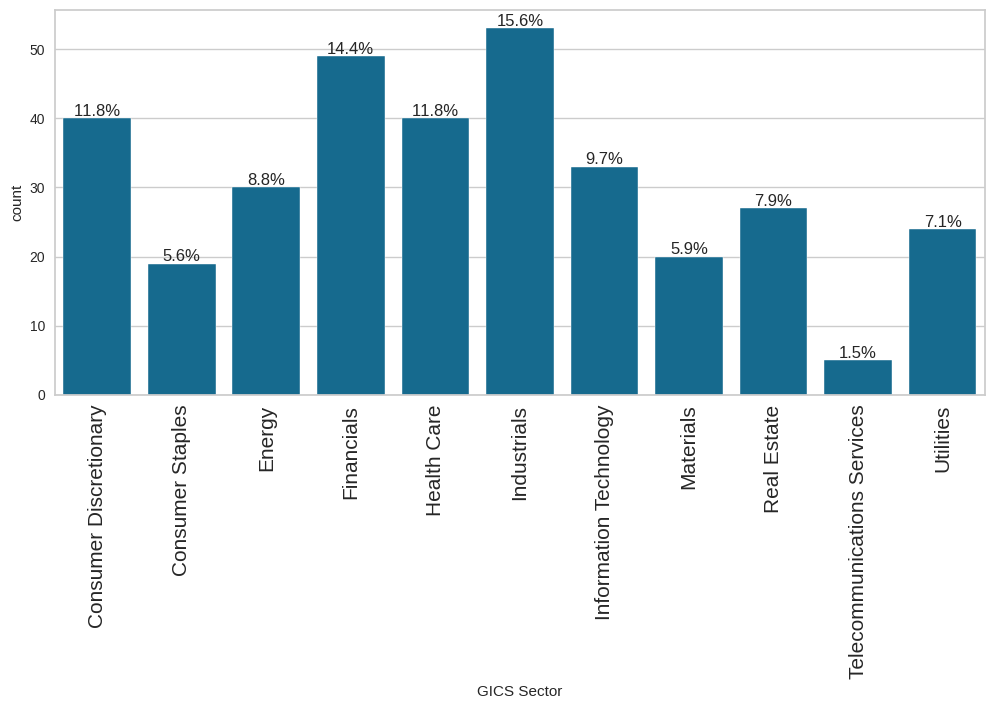

In [ ]:
# this code creates a labeled barplot of GICS Sector
labeled_barplot(df, 'GICS Sector', perc=True)

**Observations**

* Majority of the data is from the Industrials (15.6%) sector, followed by Financials (14.4%), Health Care (11.8%) and Consumer Discretionary (11.8%).

* The least data is from Telecommunications Services (1.5%).

#### *GICS Sub Industry*

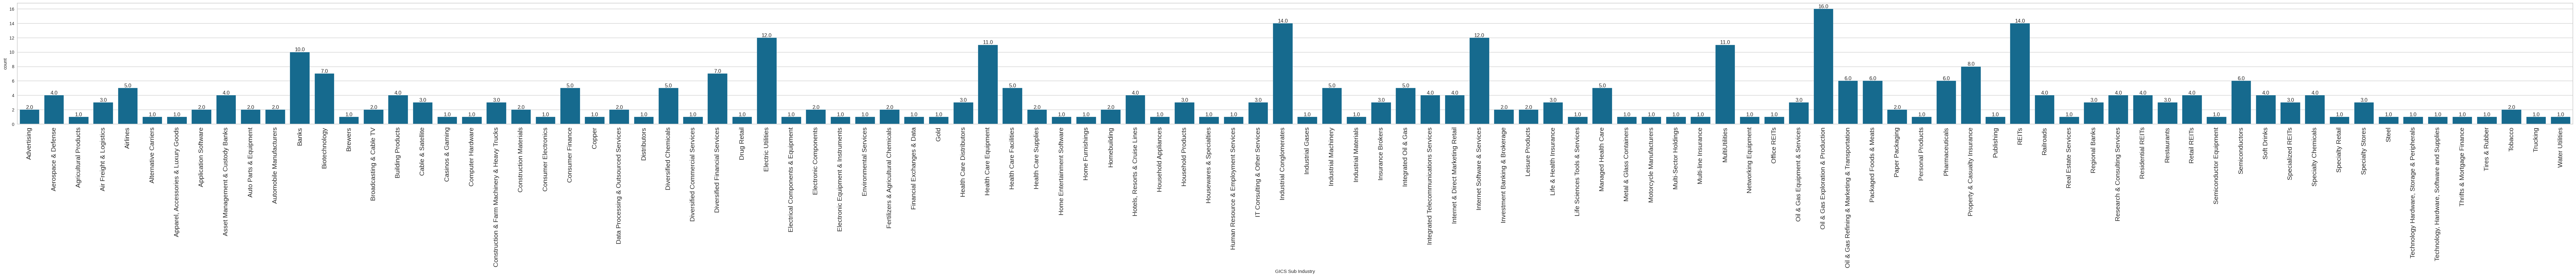

In [ ]:
# this code creates a labeled barplot of GICS Sub Industry
labeled_barplot(df, 'GICS Sub Industry')

#### *Current Price - Distribution of Stock Prices*

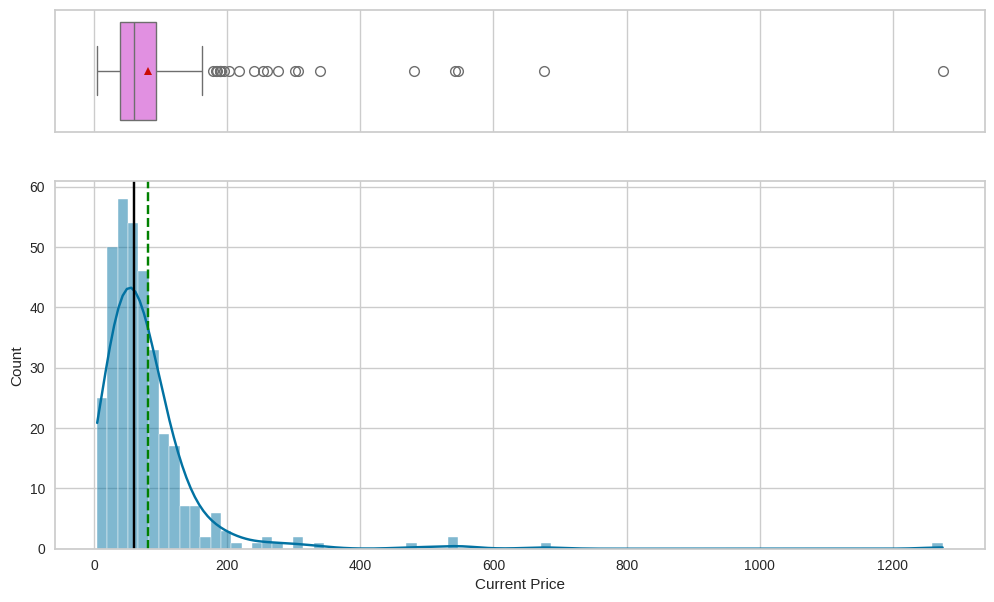

In [ ]:
# this code creates a histrogram_boxplot of the distribution of Current Price
histogram_boxplot(df, 'Current Price', kde=True)

**Observations**

* The distribution of stock prices is right skewed (positive skewed).
Majority of the stock prices are at the lower end between 0 and 200.
The tail extends towards the higher prices.

* A large majority of the stock have low prices with very few having high prices.

#### *Price Change*

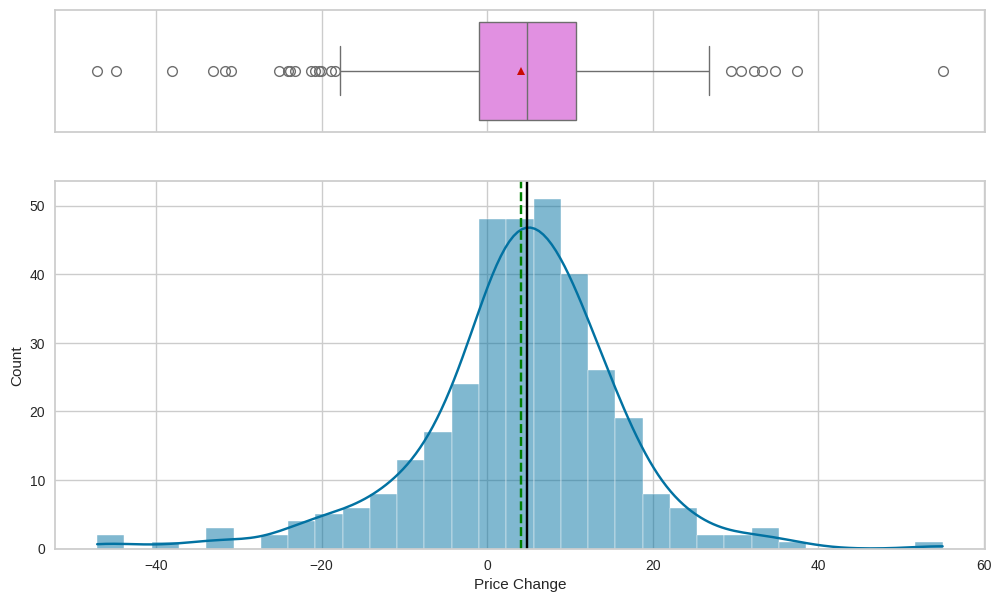

In [ ]:
# this code creates a histrogram_boxplot of the distribution of Price Change
histogram_boxplot(df, 'Price Change', kde=True)

**Observations**

* The distribution of price change is symmetical with a mean and median almost the same.

* From the boxplot, there are outliers on both the lower and upper whiskers.

#### *Volatility*

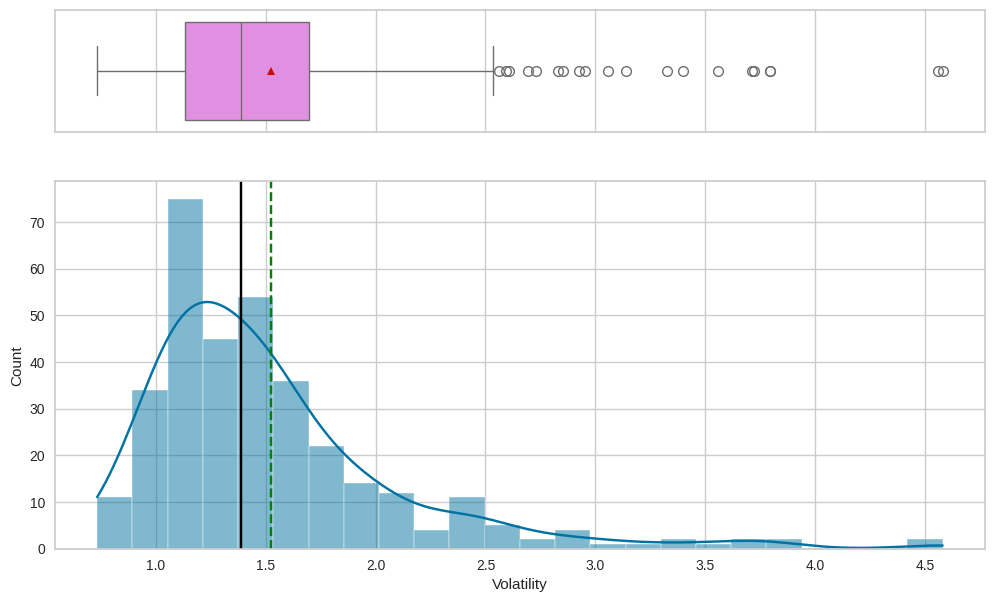

In [ ]:
# this code creates a histrogram_boxplot of the distribution of Volatility
histogram_boxplot(df, 'Volatility', kde=True)

**Observations**

* The distribution of volatility is right skewed with a long tail of values on the higher end.

* Most of the stock have lower volatility with some having higher volatility.

* There are outlier on the upper boundary in the boxplot.

#### *ROE*

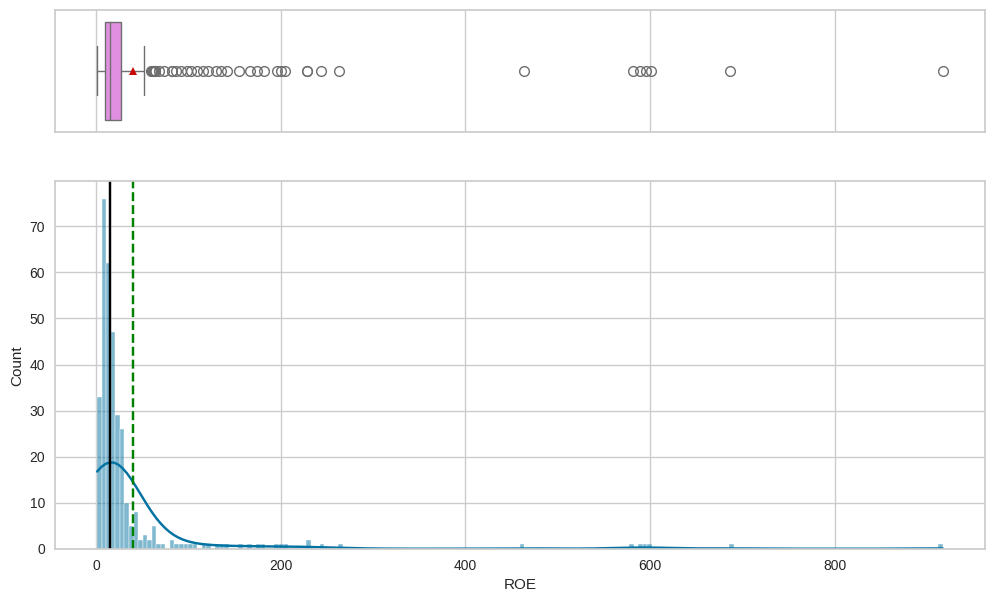

In [ ]:
# this code creates a histrogram_boxplot of the distribution of ROE
histogram_boxplot(df, 'ROE', kde=True)

**Observations**

* The distribution of ROE is right skewed.

* Majority of the stock have lower returns on equity.

* There are several outliers on the upper bound on the boxplot.

#### *Cash Ratio*

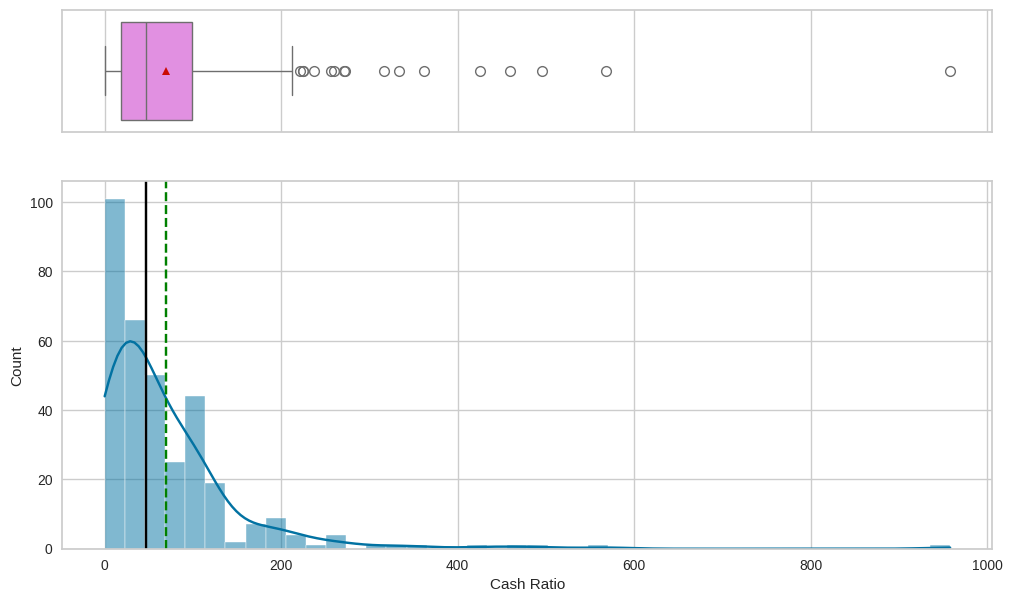

In [ ]:
# this code creates a histrogram_boxplot of the distribution of Cash Ratio
histogram_boxplot(df, 'Cash Ratio', kde=True)

**Observations**

* The distribution of cash ratio is right skewed.

* This appears to suggest that companies have more assets than liabilities indicating positive financial health.

#### *Net Cash Flow*

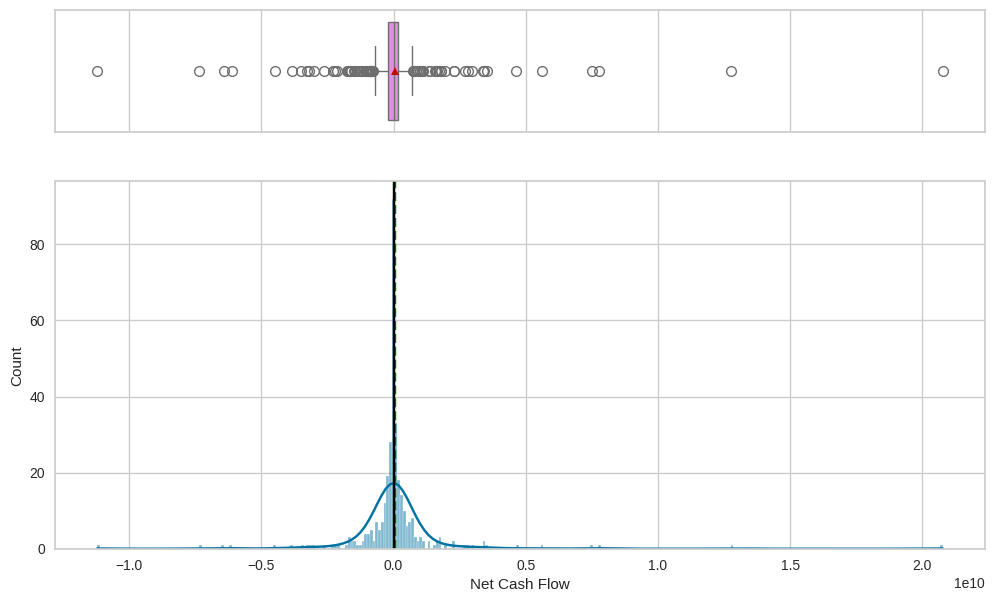

In [ ]:
# this code creates a histrogram_boxplot of the distribution of Net Cashflow
histogram_boxplot(df, 'Net Cash Flow', kde=True)

**Observations**

* The distribution of net cash flow appaears symmetrical.

* There are several outliers on the lower and upper bounds indicating that some companies may have either excess cashflow or shortfalls.

#### *Net Income*

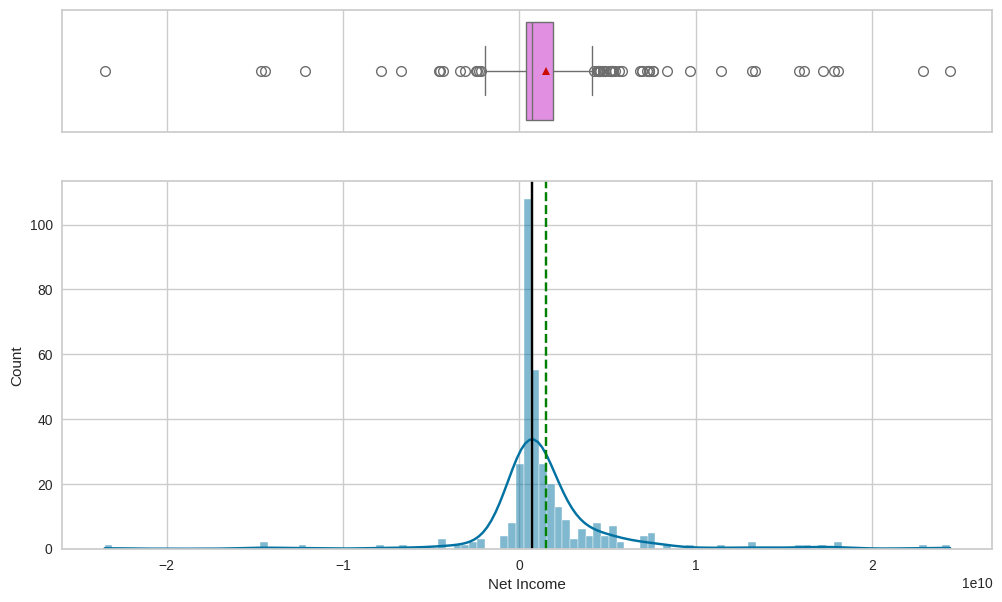

In [ ]:
# this code creates a histrogram_boxplot of the distribution of Net Income
histogram_boxplot(df, 'Net Income', kde=True)

**Observations**

* The distribution of net income appears slightly symmetrical.

* There are outliers on the lower and upper bounds.

* It appears most companies have a fairly good income but the presence of outliers may suggest some companies with relatively lower and higher incomes.

#### *Earnings Per Share*

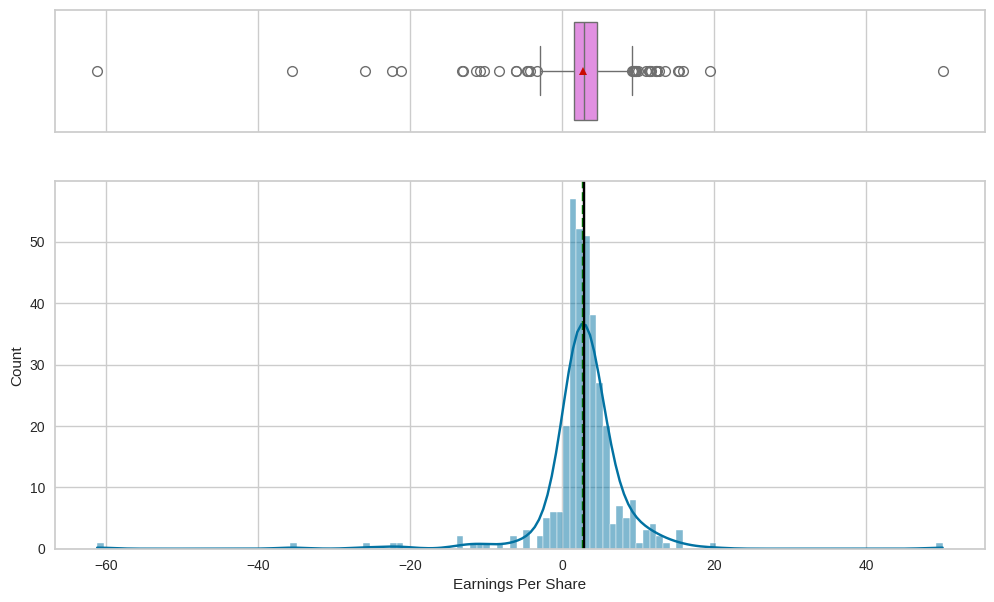

In [ ]:
# this code creates a histrogram_boxplot of the distribution of Earnings Per Share
histogram_boxplot(df, 'Earnings Per Share', kde=True)

**Observations**

* The distribution of earnings per share appears symmetrical.

* There are outliers on the lower and upper bounds of the boxplot.

* The stocks seem to have fairly good earnings per share.

#### *Estimated Shares Outstanding*

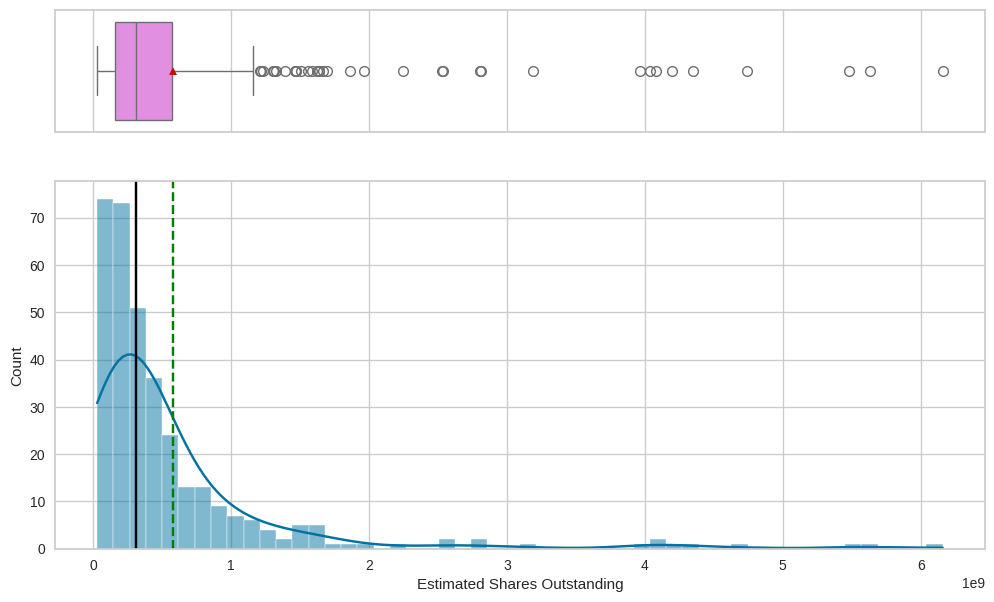

In [ ]:
# this code creates a histrogram_boxplot of the distribution of Estimated Shares Outstanding
histogram_boxplot(df, 'Estimated Shares Outstanding', kde=True)

**Observations**

* The distribution of estimated shares outstanding is right skewed.

* There are several outliers on the upper bound of the boxplot.

* This indicates that majority of shares held by shareholders are lower.

#### *P/E Ratio*

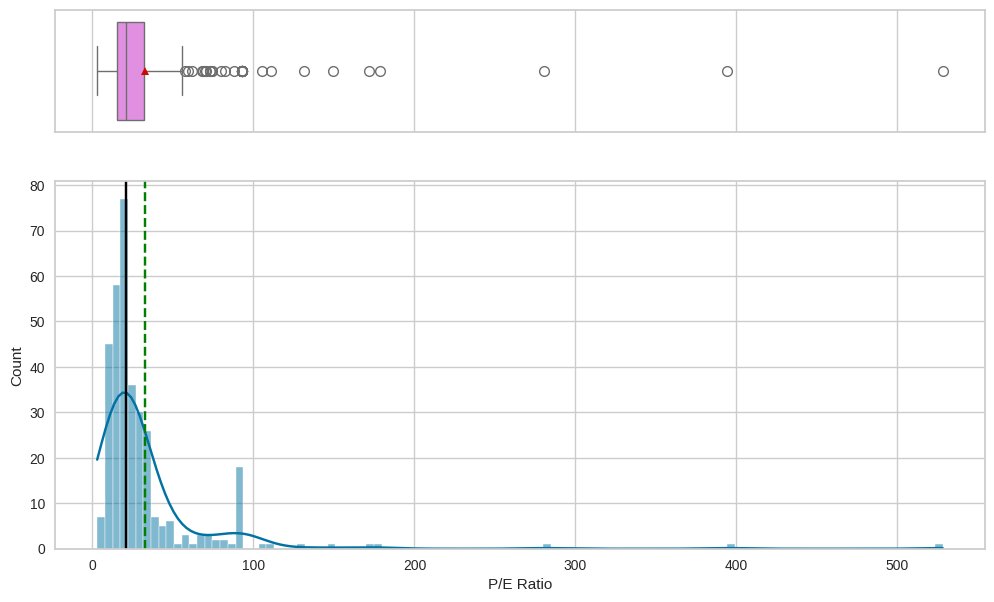

In [ ]:
# this code creates a histrogram_boxplot of the distribution of of P/E Ratio
histogram_boxplot(df, 'P/E Ratio', kde=True)

**Observations**

* The distribution of P/E ratio is right skewed with majority of the values concentrated on the lower side.

* Majority of the stocks have relatively lower prices compared to their earnings.

* There are several outliers on the upper bound indicating that there are some stocks with higher P/E ratios.

#### *P/B Ratio*

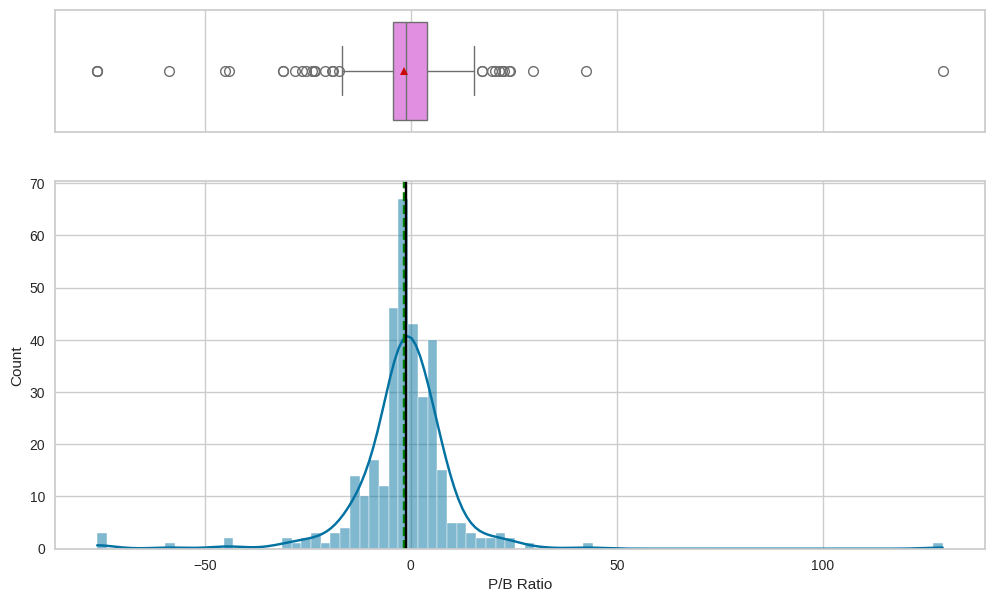

In [ ]:
# this code creates a histrogram_boxplot of the distribution of P/B Ratio
histogram_boxplot(df, 'P/B Ratio', kde=True)

**Observations**

* The distribution of P/B ratio appears symmetrical with some outliers on both the lower and upper bounds.

### Bivariate Analysis

#### Maximum price increase of stock per economic sector

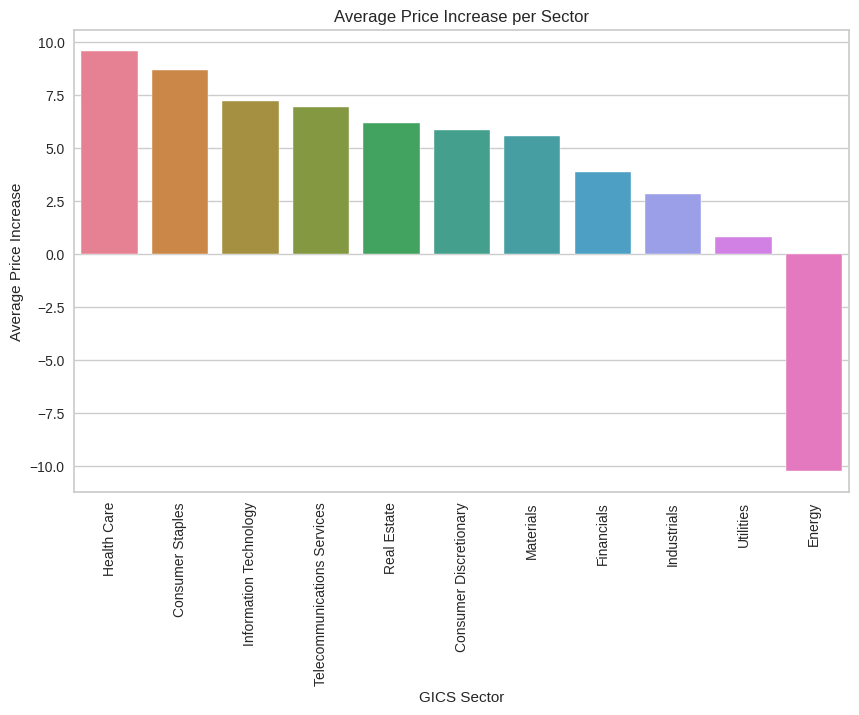

In [ ]:
# this code calculates the mean Price Change per the GCIS Sector
avg_price_increase_per_sector = df.groupby('GICS Sector')['Price Change'].mean().sort_values(ascending=False).reset_index()

# this code creates a barplot of the mean Price Change per the GCIS Sector
plt.figure(figsize=(10, 6))
sns.barplot(x='GICS Sector', y='Price Change', data=avg_price_increase_per_sector, hue='GICS Sector')
plt.title('Average Price Increase per Sector')
plt.xlabel('GICS Sector')
plt.ylabel('Average Price Increase')
plt.xticks(rotation=90)
plt.show()

**Observations:**

* On average, the stocks of the Health Care sector have seen the maximum price increase with a value close to 10.0.

* This is followed by stocks of the Consumer Staples and Information Technology.

* The stocks of the Energy sector have decreased in price.



#### Correlation between variables

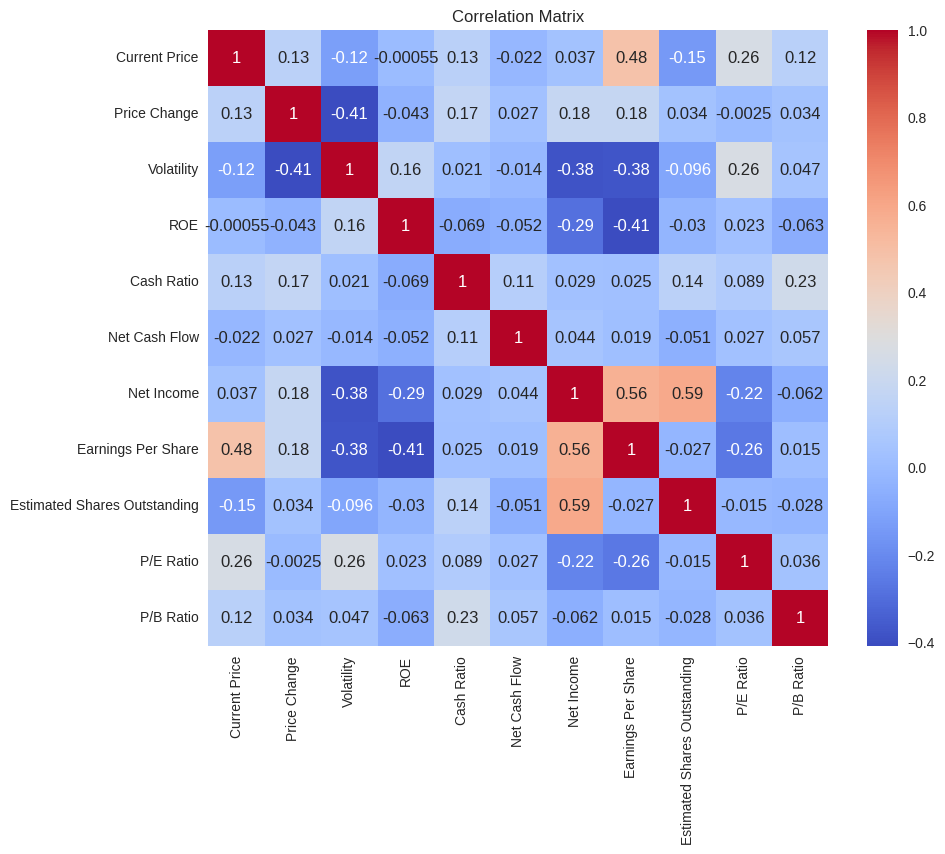

In [ ]:
# this code selects only the numeric columns
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# this code creates a correlation matrix
correlation_matrix = df[numeric_columns].corr()

# this code creates a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Observations:**

* From the heatmap, majority of the correlation between the variables are weak.

* Variables that are positively correlated with each other are:
  * Current Price and Earnings Per Share (0.48) - moderate.
  * Net Income and Earnings Per Share (0.56) - moderate.
  * Net Income and Estimated Shares Outstanding (0.59) - moderate.
* This seems to suggest that stocks with higher prices have higher earnings per share.
* In addition, companies with high net income may have high earnings per share and estimated shares outstanding.

* Noteably, variables that are strongly negatively correlated are:
  * Price Change and Volatility (-0.41).
  * Volatility and Net Income (-0.38).
  * Volatility and Earnings Per Share (-0.38).
  * ROE and Earnings Per Share (-0.41).
* This suggests an inverse relationship relationship between these variables.

#### Average Cash Ratio per Economic Sector

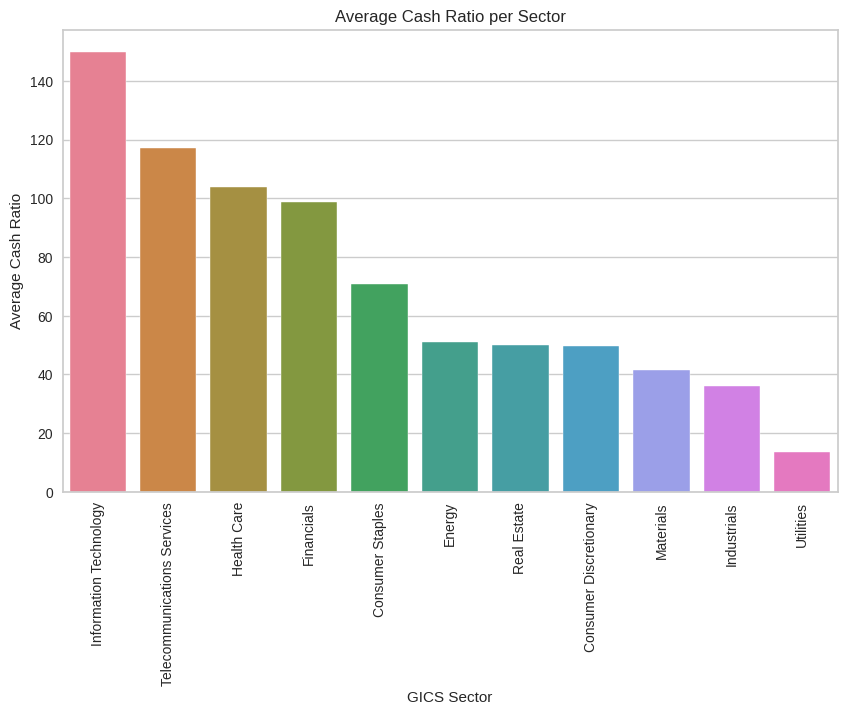

In [ ]:
# this code calculates the mean Cash Ratio for each GCIS Sector
avg_cash_ratio_per_sector = df.groupby('GICS Sector')['Cash Ratio'].mean().sort_values(ascending=False).reset_index()

# this code creates a barplot of the mean Cash Ratio for each GCIS Sector
plt.figure(figsize=(10, 6))
sns.barplot(x='GICS Sector', y='Cash Ratio', data=avg_cash_ratio_per_sector, hue='GICS Sector')
plt.title('Average Cash Ratio per Sector')
plt.xlabel('GICS Sector')
plt.ylabel('Average Cash Ratio')
plt.xticks(rotation=90)
plt.show()

**Observations:**

* Information Technology sector has the highest cash ratio, followed by Telecommunications Services, Health Care and Financials.

* The sectors with the lowest cash ratios are Utilities (least), Industrials and Materials.  

#### P/E Ratio per Economic Sector

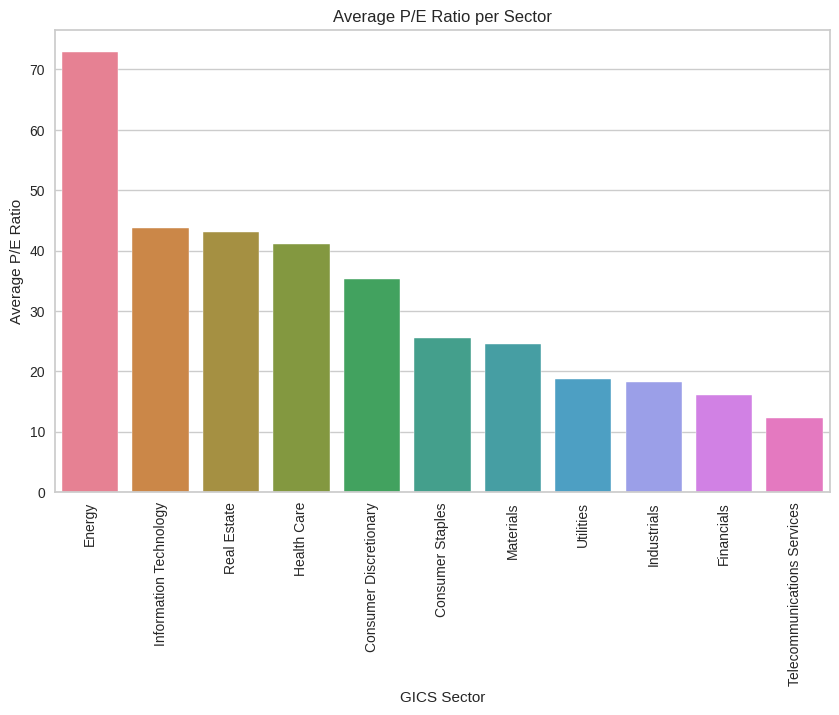

In [ ]:
# this code calculates the mean P/E Ratio for each GICS Sector
avg_pe_ratio_per_sector = df.groupby('GICS Sector')['P/E Ratio'].mean().sort_values(ascending=False).reset_index()

# this code creates a barplot of the mean P/E Ratio for each GCIS Sector
plt.figure(figsize=(10, 6))
sns.barplot(x='GICS Sector', y='P/E Ratio', data=avg_pe_ratio_per_sector, hue='GICS Sector')
plt.title('Average P/E Ratio per Sector')
plt.xlabel('GICS Sector')
plt.ylabel('Average P/E Ratio')
plt.xticks(rotation=90)
plt.show()

**Observations:**

* The P/E Ratio is the ratio of the company's current stock price to the earnings per share.

* The Energy sector has the higest P/E Ratio in comparison with other sectors.

* This is followed by the Information Technology, Real Estate and Health Care sectors.

* The sectors with the lowest P/E Ratio are Telecommunications Services, Financials and Industrials.

## Data Preprocessing

- Duplicate value check
- Missing value treatment
- Outlier check
- Feature engineering (if needed)
- Any other preprocessing steps (if needed)

### *Duplicate and Missing Value Check*

From the data overview, there are no missing values and duplicates in the data.

### *Outlier Detection and Treatment*

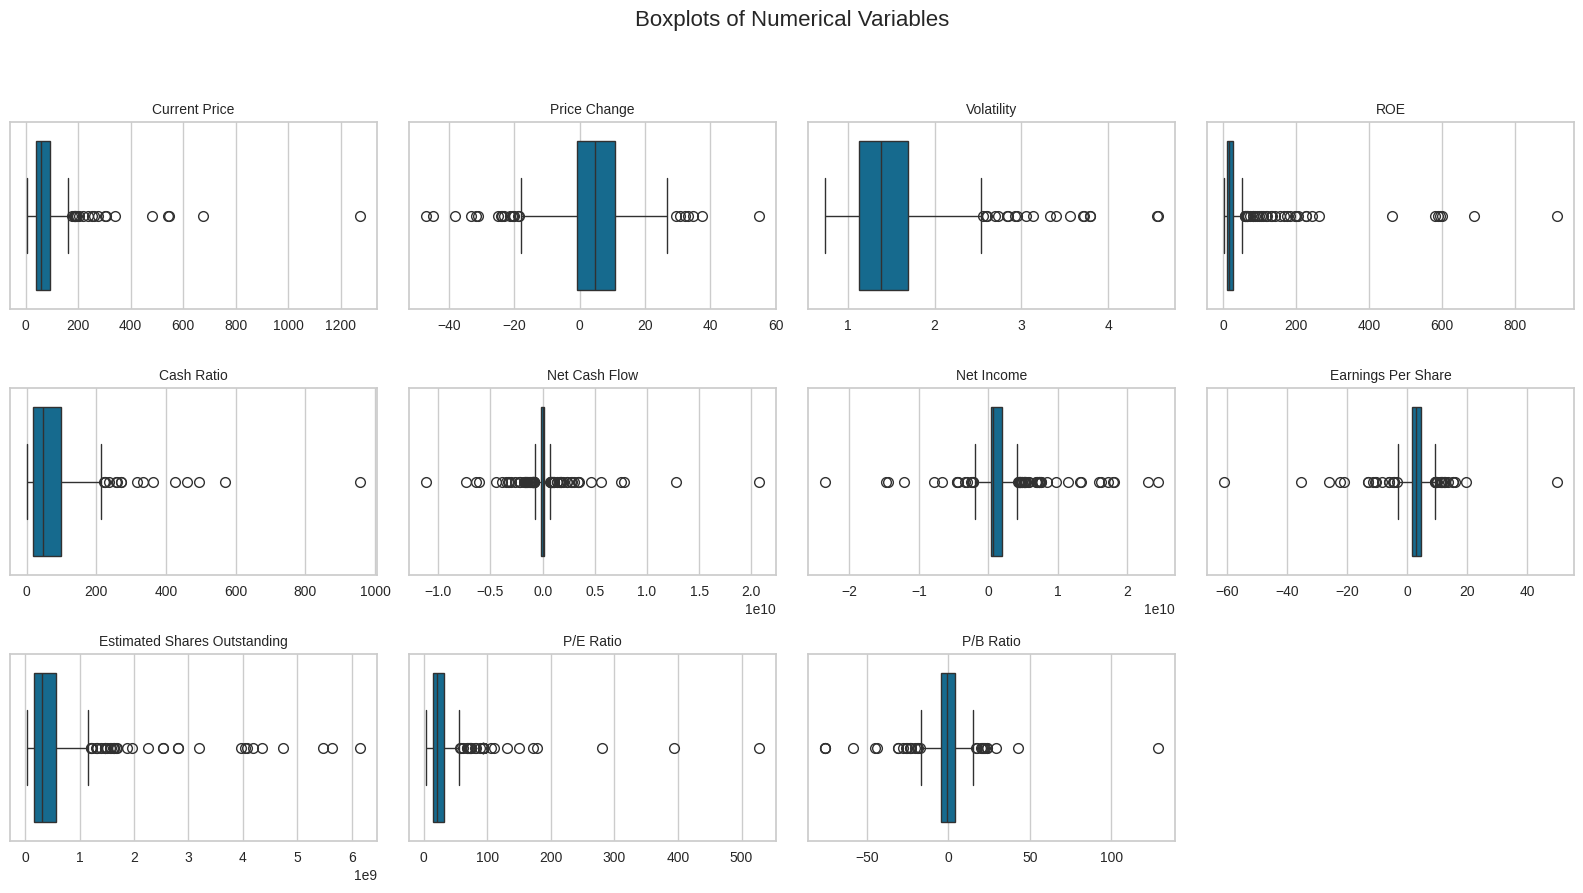

In [ ]:
# this code creates a list of numeric columns and assigns it to the variable 'numeric_columns'
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# this code calculates the optimal grid size for subplots
num_features = len(numeric_columns)

num_cols_per_row = 4
num_rows = (num_features + num_cols_per_row - 1) // num_cols_per_row

plt.figure(figsize=(num_cols_per_row * 4, num_rows * 3))
plt.suptitle('Boxplots of Numerical Variables', fontsize=16, y=1.02)

# this code visualises the outliers in the data
for i, column in enumerate(numeric_columns):
    plt.subplot(num_rows, num_cols_per_row, i + 1)
    sns.boxplot(data=df, x=column)
    plt.title(f'{column}', fontsize=10)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

**Observations:**

* There are several outliers in the numerical columns.

* The Net Cash Flow seems to have more outliers than the other variables.

* For now, the outliers will be kept for the K-Means and Hierarchical Analysis.

### *Feature Engineering*

* The ticker symbol column will be dropped because it is not useful to the analysis.

* The object-type columns will be converted to categorical to conserve the memory and prevent delays and runtime errors.

In [ ]:
# this code finds all object-type columns and saves it in the variable cols
cols = df.select_dtypes(include='object').columns.tolist()

In [ ]:
# this code converts the object type columns to category
for col in cols:
    df[col] = df[col].astype('category')

In [ ]:
# this code drops the ticker symbol column from the dataset
df.drop(['Ticker Symbol'], axis=1, inplace=True)

In [ ]:
# this code checks the info to ensure the above edits were effected
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Security                      340 non-null    category
 1   GICS Sector                   340 non-null    category
 2   GICS Sub Industry             340 non-null    category
 3   Current Price                 340 non-null    float64 
 4   Price Change                  340 non-null    float64 
 5   Volatility                    340 non-null    float64 
 6   ROE                           340 non-null    int64   
 7   Cash Ratio                    340 non-null    int64   
 8   Net Cash Flow                 340 non-null    int64   
 9   Net Income                    340 non-null    int64   
 10  Earnings Per Share            340 non-null    float64 
 11  Estimated Shares Outstanding  340 non-null    float64 
 12  P/E Ratio                     340 non-null    floa

### *Scaling*

In [ ]:
# this code applies the z-score and scales the data before clustering
scaler = StandardScaler()
subset = df.select_dtypes(include=['float64', 'int64'])
scaled_subset = scaler.fit_transform(subset)

In [ ]:
# this code creates a dataframe of the scaled data
df_scaled_subset = pd.DataFrame(scaled_subset, columns=subset.columns)

* The data was scaled by applying the z-score to each of the numerical columns.

* Hence all the columns have been standardized to have a mean of 0 and standard deviation of 1.

* This standardization is useful such that columns with large variability or ranges will not dominate the analysis.

## K-means Clustering

### *Checking Elbow Plot*

In [ ]:
# this code creates a copy of df_scaled
kmeans_df = df_scaled_subset.copy()

Number of Clusters: 1 	Average Distortion: 2.5425069919221697
Number of Clusters: 2 	Average Distortion: 2.3862098789299604
Number of Clusters: 3 	Average Distortion: 2.33620927590848
Number of Clusters: 4 	Average Distortion: 2.219050563833442
Number of Clusters: 5 	Average Distortion: 2.133404401901685
Number of Clusters: 6 	Average Distortion: 2.081503686093715
Number of Clusters: 7 	Average Distortion: 2.0045413402786814
Number of Clusters: 8 	Average Distortion: 1.9864237824874411
Number of Clusters: 9 	Average Distortion: 1.956222103389025
Number of Clusters: 10 	Average Distortion: 1.9360473996664198
Number of Clusters: 11 	Average Distortion: 1.8615942883461607
Number of Clusters: 12 	Average Distortion: 1.8219574388532505
Number of Clusters: 13 	Average Distortion: 1.7936924742607907
Number of Clusters: 14 	Average Distortion: 1.7567842179093438


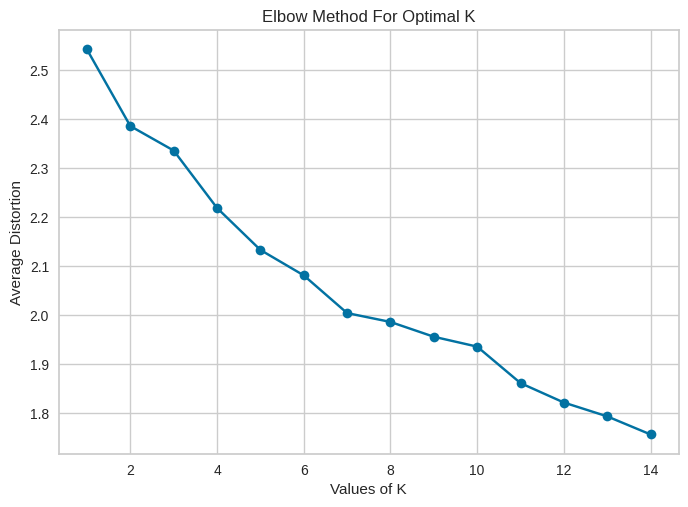

In [ ]:
# this code uses the elbow plot to determine the optimal number of clusters
cluster = range(1, 15)
meanDistortions = []

for k in cluster:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(kmeans_df)
    prediction = kmeans.predict(kmeans_df)
    distortion = (
        sum(np.min(cdist(kmeans_df, kmeans.cluster_centers_, "euclidean"), axis=1))
        / kmeans_df.shape[0]
    )
    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(cluster, meanDistortions, marker='o')
plt.xlabel("Values of K")
plt.ylabel("Average Distortion")
plt.title("Elbow Method For Optimal K")
plt.show()

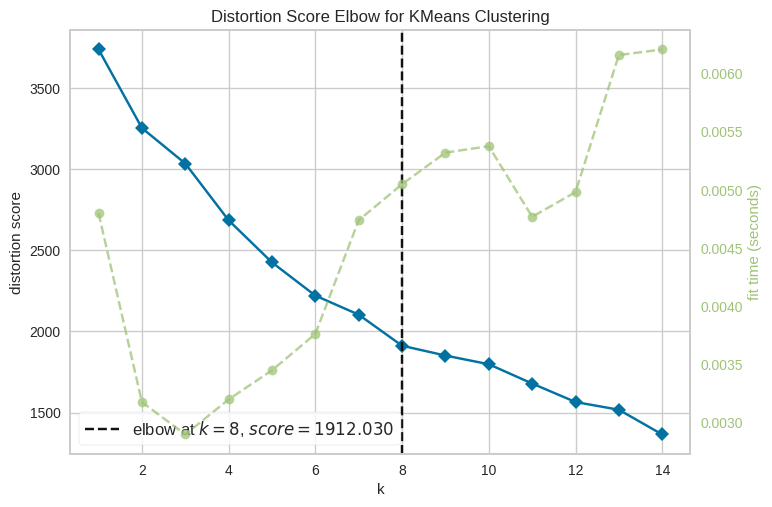

In [ ]:
# this code creates the model and fits the data
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(1, 15), timings=True)
visualizer.fit(kmeans_df)
visualizer.show();

### *Silhouette Scores*

For n_clusters = 2, silhouette score is 0.45335782729503565
For n_clusters = 3, silhouette score is 0.40374060030338865
For n_clusters = 4, silhouette score is 0.4246430808437099
For n_clusters = 5, silhouette score is 0.4381539778147092
For n_clusters = 6, silhouette score is 0.40869599703024256
For n_clusters = 7, silhouette score is 0.1207450219233897
For n_clusters = 8, silhouette score is 0.3693991650696542
For n_clusters = 9, silhouette score is 0.35185096182499204
For n_clusters = 10, silhouette score is 0.32950073703610283
For n_clusters = 11, silhouette score is 0.1486586842527321
For n_clusters = 12, silhouette score is 0.15784241071085106
For n_clusters = 13, silhouette score is 0.15646997458716602
For n_clusters = 14, silhouette score is 0.16253506827999134


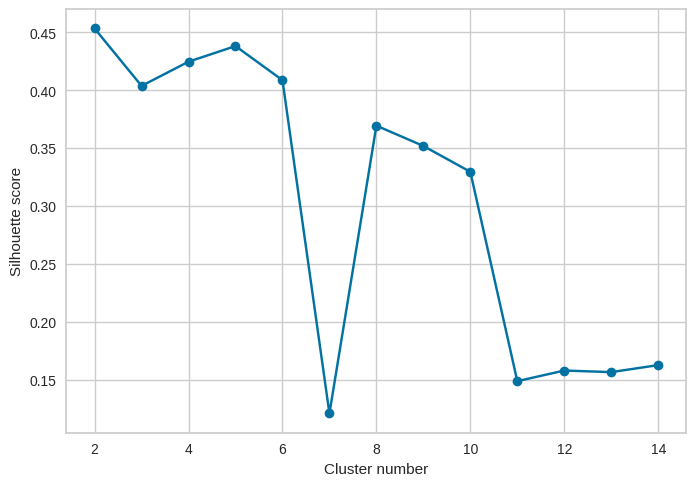

In [ ]:
# this code calculates and visualizes the silhouette scores for the clusters
sil_score =[]
cluster_list = range(2, 15)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1, n_init='auto')
    preds = clusterer.fit_predict((kmeans_df))
    score = silhouette_score(kmeans_df, preds)
    sil_score.append(score)
    print(f"For n_clusters = {n_clusters}, silhouette score is {score}")

plt.plot(cluster_list, sil_score, marker='o')
plt.xlabel('Cluster number')
plt.ylabel('Silhouette score')
plt.show()

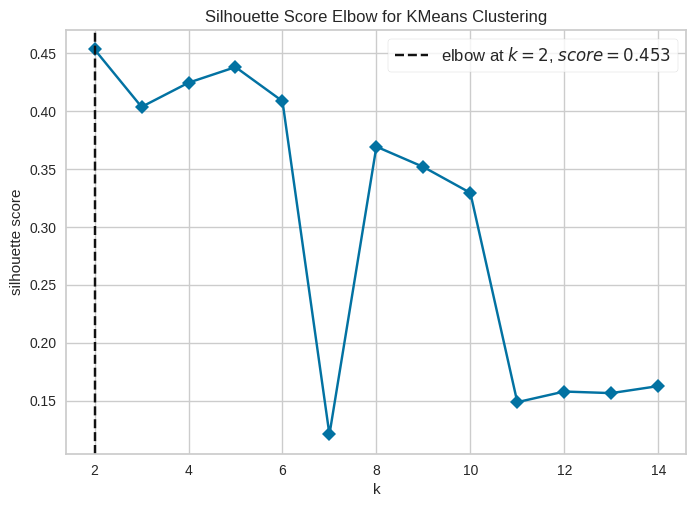

In [ ]:
# this code visualizes silhouette scores using KElbowVisualizer to help determine the optimal number of clusters
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 15), metric='silhouette', timings=False)
visualizer.fit(kmeans_df)
visualizer.show();

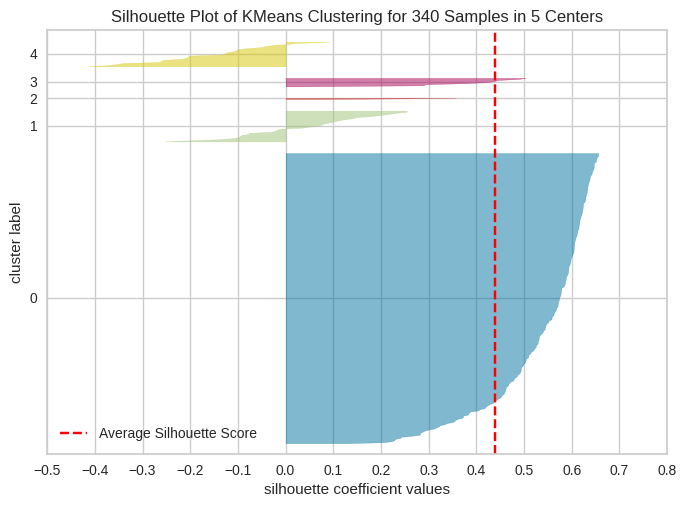

In [ ]:
# this code visualizes the silhouette plot for a chosen number of clusters
visualizer = SilhouetteVisualizer(KMeans(n_clusters=5, random_state=1, n_init='auto'), colors='yellowbrick')
visualizer.fit(kmeans_df)
visualizer.show();

### *Final Model*

In [ ]:
# this code creates the final K-Means model
kmeans = KMeans(n_clusters=5, random_state=1)
kmeans.fit(kmeans_df)

KMeans(n_clusters=5, random_state=1)

In [ ]:
# this code creates a copy of the original dataframe
df_copy = df.copy()

In [ ]:
# this code adds KMeans cluster labels to the original and scaled dataframes
kmeans_df["KM_segments"] = kmeans.labels_
df_copy["KM_segments"] = kmeans.labels_

### *Cluster Profiling*

In [ ]:
# this code groupsby the cluster labels
km_cluster_profile = df_copy.groupby('KM_segments').mean(numeric_only=True)

km_cluster_profile['count'] = (
    df_copy.groupby('KM_segments')['Security'].count().values
)

km_cluster_profile.style.highlight_max(color='green', axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,count
KM_segments,,,,,,,,,,,,
0,72.738269,5.179897,1.380738,34.825455,53.138182,-10147287.272727,1488641570.909091,3.636164,437961614.918582,23.680917,-3.395254,275
1,65.106668,-11.888125,2.722141,44.000000,61.400000,-36858300.000000,-2137169366.666667,-5.560333,529714171.048000,113.488924,0.905486,30
2,24.485001,-13.351992,3.482611,802.000000,51.000000,-1292500000.000000,-19106500000.000000,-41.815000,519573983.250000,60.748608,1.565141,2
3,46.672222,5.166566,1.079367,25.000000,58.333333,-3040666666.666667,14848444444.444445,3.435556,4564959946.222222,15.596051,-6.354193,9
4,211.164720,12.456786,1.699388,30.708333,280.250000,2197085166.666667,2808600583.333333,6.818333,738957421.659167,37.895420,15.682619,24


In [ ]:
# this code prints the companies in each cluster
for cl in df_copy['KM_segments'].unique():
  print('In cluster{}, the following companies are present:'.format(cl))
  print(df_copy[df_copy['KM_segments'] == cl]['Security'].unique())
  print()

In cluster0, the following companies are present:
['American Airlines Group', 'AbbVie', 'Abbott Laboratories', 'Adobe Systems Inc', 'Archer-Daniels-Midland Co', ..., 'Xylem Inc.', 'Yum! Brands Inc', 'Zimmer Biomet Holdings', 'Zions Bancorp', 'Zoetis']
Length: 275
Categories (340, object): ['3M Company', 'AFLAC Inc', 'AMETEK Inc', 'AT&T Inc', ...,
                           'Zimmer Biomet Holdings', 'Zions Bancorp', 'Zoetis', 'eBay Inc.']

In cluster1, the following companies are present:
['Analog Devices, Inc.', 'Alexion Pharmaceuticals', 'Amazon.com Inc', 'Anadarko Petroleum Corp', 'Baker Hughes Inc', ..., 'Spectra Energy Corp.', 'Southwestern Energy', 'Teradata Corp.', 'Williams Cos.', 'Cimarex Energy']
Length: 30
Categories (340, object): ['3M Company', 'AFLAC Inc', 'AMETEK Inc', 'AT&T Inc', ...,
                           'Zimmer Biomet Holdings', 'Zions Bancorp', 'Zoetis', 'eBay Inc.']

In cluster4, the following companies are present:
['Alliance Data Systems', 'Amgen Inc', 'Bank 

In [ ]:
# this code uses the groupby method to count the unique values of KM_segments and GICS Sector
df_copy.groupby(['KM_segments', 'GICS Sector'])['Security'].count()

KM_segments  GICS Sector                
0            Consumer Discretionary         33
             Consumer Staples               17
             Energy                          5
             Financials                     45
             Health Care                    29
             Industrials                    52
             Information Technology         24
             Materials                      18
             Real Estate                    26
             Telecommunications Services     2
             Utilities                      24
1            Consumer Discretionary          1
             Consumer Staples                0
             Energy                         21
             Financials                      0
             Health Care                     1
             Industrials                     1
             Information Technology          4
             Materials                       2
             Real Estate                     0
             Telecommunications Services     0
             Utilities                       0
2            Consumer Discretionary          0
             Consumer Staples                0
             Energy                          2
             Financials                      0
             Health Care                     0
             Industrials                     0
             Information Technology          0
             Materials                       0
             Real Estate                     0
             Telecommunications Services     0
             Utilities                       0
3            Consumer Discretionary          1
             Consumer Staples                1
             Energy                          1
             Financials                      3
             Health Care                     1
             Industrials                     0
             Information Technology          0
             Materials                       0
             Real Estate                     0
             Telecommunications Services     2
             Utilities                       0
4            Consumer Discretionary          5
             Consumer Staples                1
             Energy                          1
             Financials                      1
             Health Care                     9
             Industrials                     0
             Information Technology          5
             Materials                       0
             Real Estate                     1
             Telecommunications Services     1
             Utilities                       0
Name: Security, dtype: int64

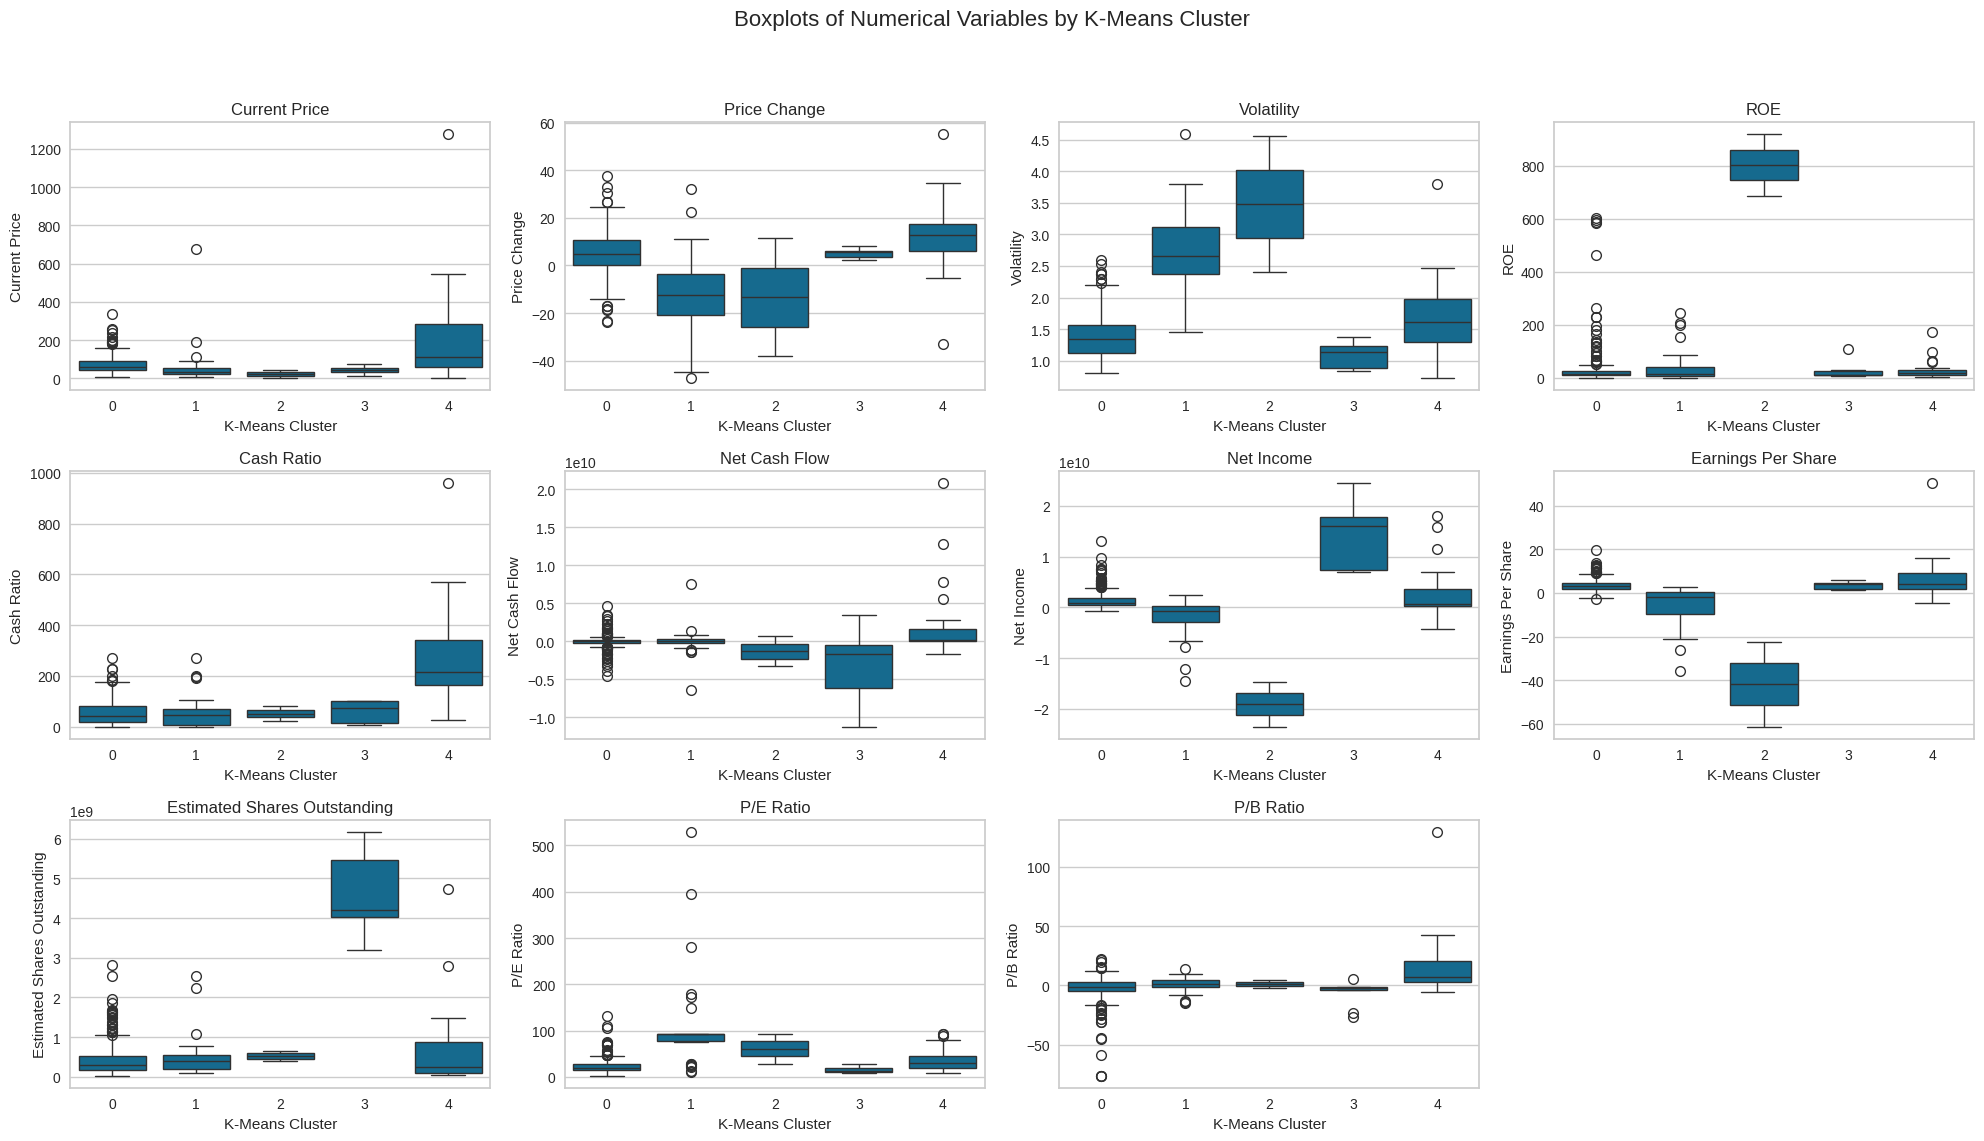

In [ ]:
# this code selects only the numerical columns from df_copy, excluding the cluster labels themselves
num_cols_km = df_copy.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'KM_segments' in num_cols_km:
    num_cols_km.remove('KM_segments')

# this code calculates the optimal grid size for subplots
num_features_km = len(num_cols_km)
num_rows_km = (num_features_km + 3) // 4
num_cols_grid_km = 4

# this code visualized the numerical variables by K-Means Cluster
plt.figure(figsize=(num_cols_grid_km * 5, num_rows_km * 4))
plt.suptitle('Boxplots of Numerical Variables by K-Means Cluster', fontsize=16)

for i, col in enumerate(num_cols_km):
    plt.subplot(num_rows_km, num_cols_grid_km, i + 1)
    sns.boxplot(x='KM_segments', y=col, data=df_copy)
    plt.title(f'{col}')
    plt.xlabel('K-Means Cluster')
    plt.ylabel(col)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Observations

* From the elbow plot, there is significant decrease in the distortion from cluster 1 to 2. The decreases continues to about 5 clusters. After 5 clusters, the decrease continues but it appears more steady. Hence the decrease in the distortion beyond this point is less.

* From the average distortion values, the distortion decreases from:
  * 2.54 (Cluster 1) to 2.38 (Cluster 2) - significant drop of 0.156.
  * 2.38 (Cluster 2) to 2.33 (Cluster 3) - drop of 0.050
  * 2.33 (Cluster 3) to 2.21 (Cluster 4) - significant drop of 0.117
  * 2.21 (Cluster 4) to 2.13 (Cluster 5) - significant drop of 0.086
  * 2.13 (Cluster 5) to 2.08 (Cluster 6) - comparable drop of 0.052
  * 2.08 (Cluster 6) to 2.00 (Cluster 7) - drop of 0.077
  * 2.00 (Cluster 7) to 1.98 (Cluster 8) - drop of 0.018
  * 1.98 (Cluster 8) to 1.95 (Cluster 9) - drop of 0.030
  * 1.95 (Cluster 9) to 1.93 (Cluster 10) - drop of 0.020
  * 1.93 (Cluster 10) to 1.86 (Cluster 11) - drop of 0.07
  * 1.86 (Cluster 11) to 1.82 (Cluster 12) - drop of 0.039
  * 1.82 (Cluster 12) to 1.79 (Cluster 13) - drop of 0.028
  * 1.79 (Cluster 13) to 1.75 (Cluster 14) - drop of 0.036

* After 5 clusters, the decrease is less significant and adding more clusters does not have any signigicant effect.

* The highest silhouette score is observed at cluster 2 (0.453). This is followed closely by cluster 5 (0.438) and cluster 4 (0.425).

* There is a noteaceble and significant drop in the silhouette score when moving from cluster 6 to cluster 7. However, more than 6 clusters does not seam ideal.

* Cluster 2 has the highest silhouette score and comparably, in the elbow plot cluster 2 had the most significant drop. However, 2 clusters does not seem ideal relative to 5 clusters.

* 5 clusters provides more meaningful and distincts segments for indepth analysis.

* In order to provide indepth and diverse feedback for Trade & Ahead, 5 clusters will be more informative than 2 clusters.

### Insights

*   **Cluster 0** is the largest cluster and has maority of the stocks. There are 275 companies in this cluster. The performance on average is good across the various financial metrics.
    * The companies generally show moderate values across most metrics. The current price, price change, and volatility are close to the overall dataset mean. Tbe net income and earnings per share are positive but not high. The net cash flow and P/B ratio are negative.
    * There are more industrial (52) and financial (45) companies. It appears to be suitable for investors who are interested in diversifying with moderate risk. It is important to note that, there is likely to be companies that are high performers in this cluster. Further analysis may be required to identify them and differentiate between extremely high and low performers.

*   **Cluster 1** is relatively small compared with cluster 0 and has 30 companies. The stocks seems to have lower prices and higher volatility and high P.E Ratio.
    * This cluster has a significant number of Energy sector companies (21 out of 30). It appears perform below average on the financial metrics such as the current price, significant negative price change high volatility, low ROE and negative net cash flow, net income and earnings per share.
    * The stocks in this cluster may less profitable and high risk. To investors with low risk tolerance, it will not be advisable to invest in these stocks. Investors with high risk tolerance, who are more adventerous and prioritize long term growth may invest in such stocks.

*   **Cluster 2** is the smallest with only 2 companies. It is likely these companies may be high specialized or there are several outliers present. The stocks in this cluster have the highest volatility and ROE.
    * This is a very small cluster with 'Apache Corporation' and 'Chesapeake Energy'. Both companies are in the Energy sector. The stocks in this cluste have the lowest current prices and the highest negative price changes, and volatility. The net cash flow, net income and earnisgs per share are significantly high Conversely, the ROE is extremely high.
    * There appears to be significant losses with these stocks and this is generally not attractive for many investors. However, taking into consideration the high ROE, investors who are extremely high risk tolerant may venture into such stocks.

*   **Cluster 3** is a smaller cluster with 9 companies. The net income and estimated shares outstanding are very high.
    * This cluster contains some commonly known companies like 'Citigroup Inc.', 'JPMorgan Chase & Co.', 'Coca Cola Company', 'Pfizer Inc.', 'AT&T Inc', 'Verizon Communications', 'Wells Fargo', 'Exxon Mobil Corp.'. They typically have moderate current prices, the lowest volatility, and highest positive net income and estimated shares outstanding.
    * This cluster appears attractive first because of the well know companies. Second, the performance of the stocks on average are stable and consistent although they do not seem appreciate significantly high. Moderate risk and conservative investors are more suited for these stocks.

*   **Cluster 4** is a small cluster with 24 companies. The stocks in this cluster have the highest values across several financial metrics including current price, price change, cash ratio, net cash flow, earnings per share and P.B ratio.
    * The stock in this cluster have the highest current prices, price change, cash ratio, earnings per share, and P/B Ratio. Volatility is low.
    * This cluster has high appreciation of stock and investors who seek growth are suited for it.

## Hierarchical Clustering

### *Cophenetic Correlation*

In [ ]:
# creates a copy of the scaled_subset for hierarchical clustering
hc_df = df_scaled_subset.copy()

In [ ]:
# this code creates a list of distance metrics
distance_metrics = ['euclidean', 'chebyshev', 'cityblock']

# this code creates a list of linkage methods
linkage_methods = ['single', 'complete', 'average', 'ward']

In [ ]:
# this code computes the cophenetic correlation on hc_df with the distance metrics and linkage methods
high_cophenet_corr = 0
high_dm_result = ''
high_lm_result = ''

for dm in distance_metrics:
    for lm in linkage_methods:
        # method 'ward' only works with 'euclidean' metric
        if lm == 'ward' and dm != 'euclidean':
            print(f'Skipping {dm.capitalize()} distance and {lm} linkage (incompatible).')
            continue

        Z = linkage(hc_df, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(hc_df))
        print(f'Cophenetic correlation for {dm.capitalize()} distance and {lm} linkage: {c:.2f}')
        if c > high_cophenet_corr:
            high_cophenet_corr = c
            high_dm_result = dm
            high_lm_result = lm

print('*' * 100)
print(
    f'The highest cophenet_correlation is {high_cophenet_corr:.2f} between {high_dm_result} and {high_lm_result}.'
)


Cophenetic correlation for Euclidean distance and single linkage: 0.92
Cophenetic correlation for Euclidean distance and complete linkage: 0.79
Cophenetic correlation for Euclidean distance and average linkage: 0.94
Cophenetic correlation for Euclidean distance and ward linkage: 0.71
Cophenetic correlation for Chebyshev distance and single linkage: 0.91
Cophenetic correlation for Chebyshev distance and complete linkage: 0.60
Cophenetic correlation for Chebyshev distance and average linkage: 0.93
Skipping Chebyshev distance and ward linkage (incompatible).
Cophenetic correlation for Cityblock distance and single linkage: 0.93
Cophenetic correlation for Cityblock distance and complete linkage: 0.74
Cophenetic correlation for Cityblock distance and average linkage: 0.93
Skipping Cityblock distance and ward linkage (incompatible).
****************************************************************************************************
The highest cophenet_correlation is 0.94 between euclidean a

In [ ]:
# this code computes the cophenetic correlation with Euclidean distance only
linkage_methods = ['single', 'complete', 'average', 'ward']

high_cophenet_corr = 0
high_dm_result = ''
high_lm_result = ''

for lm in linkage_methods:
    Z = linkage(hc_df, metric='euclidean', method=lm)
    c, coph_dists = cophenet(Z, pdist(hc_df))
    print(f'Cophenetic correlation for Euclidean distance and {lm} linkage: {c:.2f}')
    if c > high_cophenet_corr:
        high_cophenet_corr = c
        high_dm_result = 'Euclidean'
        high_lm_result = lm

print('*' * 100)
print(f'The highest cophenetic correlation is {high_cophenet_corr:.2f} between {high_dm_result} and {high_lm_result}.')

Cophenetic correlation for Euclidean distance and single linkage: 0.92
Cophenetic correlation for Euclidean distance and complete linkage: 0.79
Cophenetic correlation for Euclidean distance and average linkage: 0.94
Cophenetic correlation for Euclidean distance and ward linkage: 0.71
****************************************************************************************************
The highest cophenetic correlation is 0.94 between Euclidean and average.


**Observations:**

* Euclidean distance and average linkage have the highest cophenetic correlation coefficient of 0.94. Average linkage has a consistently high cophenetic correlation coefficient across all the other distance metrics 0.93.

* Single linkage also has a high cophenetic correlation of 0.93 (Cityblock), 0.92 (Euclidean), and 0.91 (Chebyshev).

* Complete linkage consistently has lower correlation coefficents across the distance metrics.

* The Euclidean distance and average linkage provides the best representation and will result in a dendrogram that displays accurate distance in the stock data points. These would be used to build the hierarchical clustering model.

### *Checking Dendrograms*

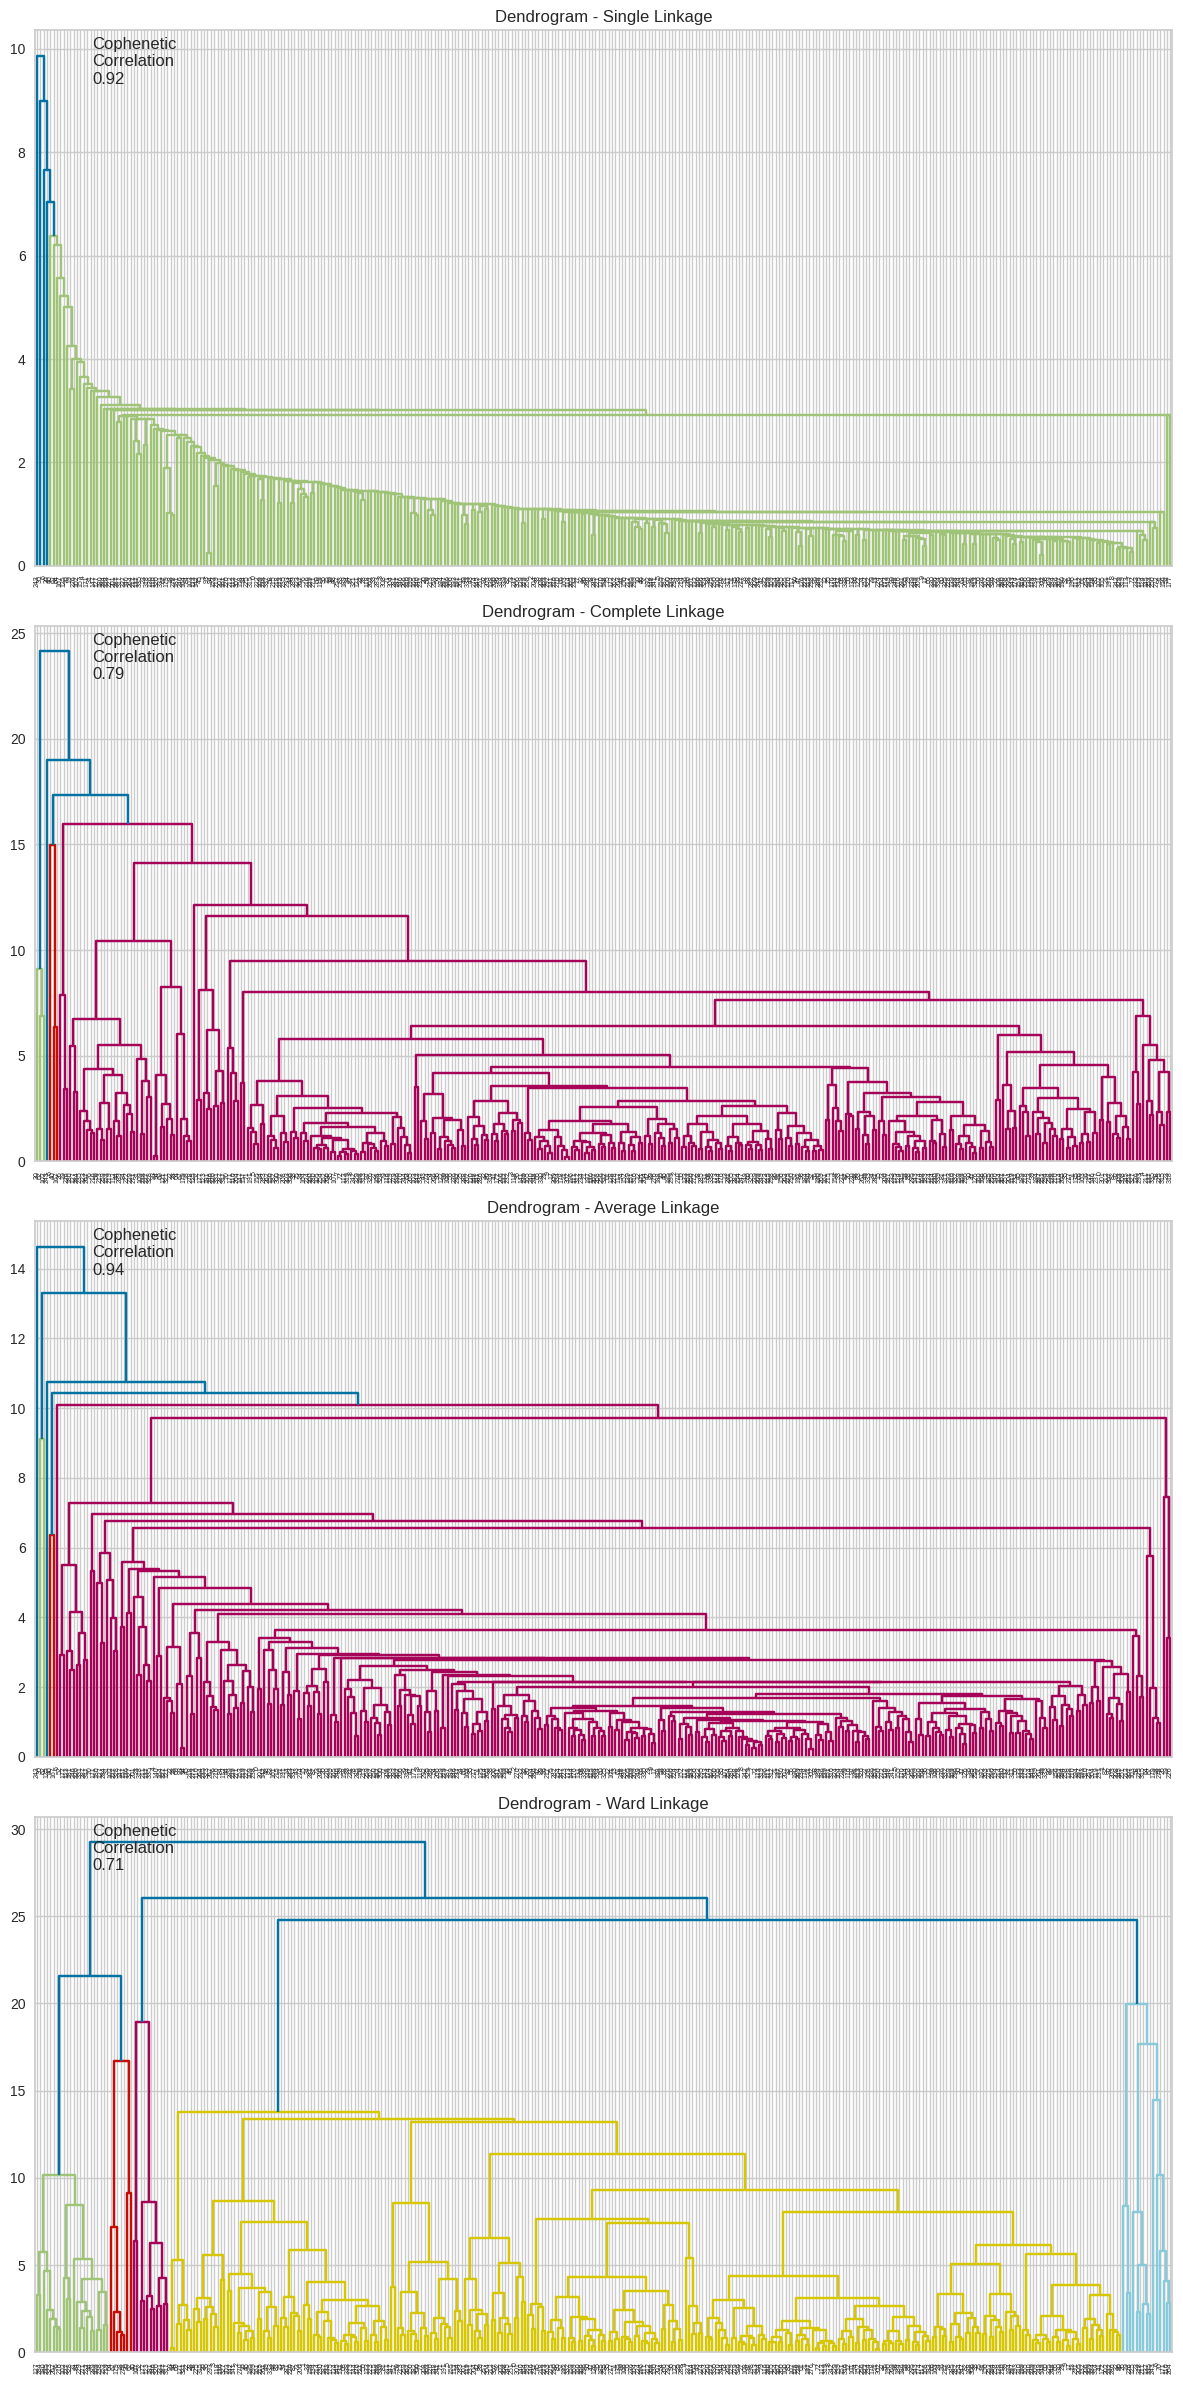

In [ ]:
# this code list the linkage methods
linkage_methods = ['single', 'complete', 'average', 'ward']

# this code creates a list to save the results of the cophenetic correlation
compare_cols = ['Linkage', 'Cophenetic Coefficient']
compare = []

# this code creates a subplot image
fig, axes = plt.subplots(len(linkage_methods), 1, figsize=(12, 24))

# this code plots the dendrogram and calculates the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(hc_df, metric='euclidean', method=method)

    dendrogram(Z, ax=axes[i])
    axes[i].set_title(f'Dendrogram - {method.capitalize()} Linkage')

    coph_corr, coph_dists = cophenet(Z, pdist(hc_df))
    axes[i].annotate(
        f'Cophenetic\nCorrelation\n{coph_corr:.2f}',
         (0.05, 0.9), xycoords='axes fraction')

    compare.append([method, c])
plt.tight_layout()
plt.show()

The Cophenetic Coefficient is highest for Average Linkage - 0.94, followed by single linkage - 0.92

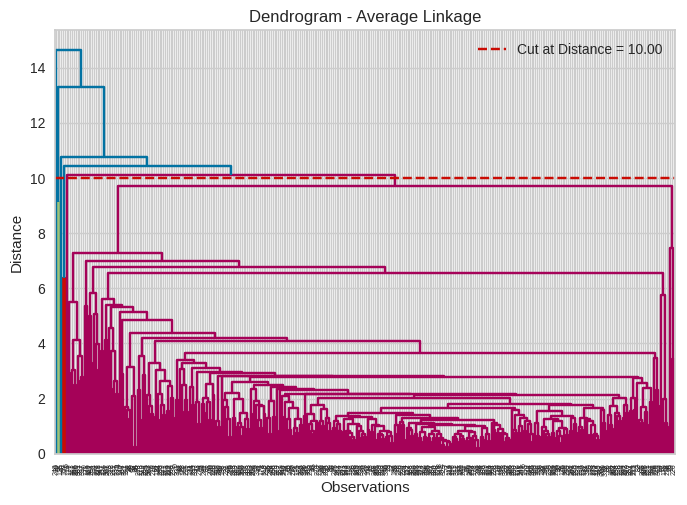

In [ ]:
# this code visualizes the average linkage
Z = linkage(hc_df, metric='euclidean', method='average')
dendrogram(Z)
plt.title('Dendrogram - Average Linkage')
plt.xlabel('Observations')
plt.ylabel('Distance')


cut_distance = 10.0
plt.axhline(y=cut_distance, color='r', linestyle='--', label=f'Cut at Distance = {cut_distance:.2f}')
plt.legend()


plt.show()

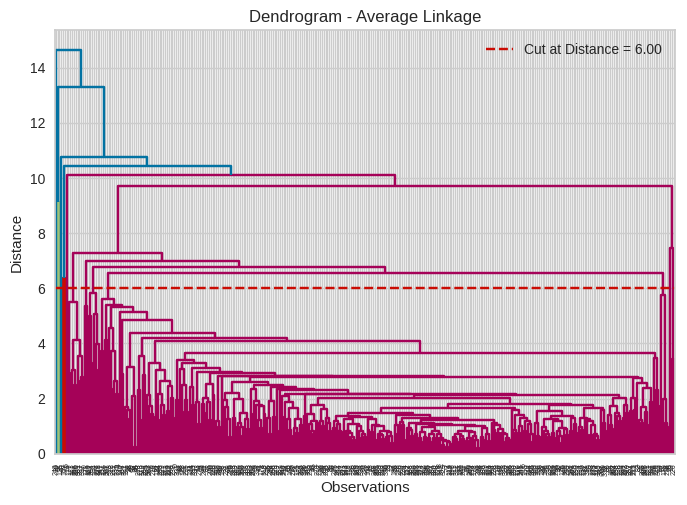

In [ ]:
# this code visualizes the average linkage
Z = linkage(hc_df, metric='euclidean', method='average')
dendrogram(Z)
plt.title('Dendrogram - Average Linkage')
plt.xlabel('Observations')
plt.ylabel('Distance')


cut_distance = 6.0
plt.axhline(y=cut_distance, color='r', linestyle='--', label=f'Cut at Distance = {cut_distance:.2f}')
plt.legend()


plt.show()

### *sklearn Model*

In [ ]:
# this code
HCmodel = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
HCmodel.fit(hc_df)

AgglomerativeClustering(n_clusters=5)

In [ ]:
# this code creates a copy of the original data
df1_copy = df.copy()

In [ ]:
# this code adds the hierarchical cluster labels to the original and scaled dataframes
df1_copy["HC_segments"] = HCmodel.labels_
hc_df["HC_segments"] = HCmodel.labels_

### *Cluster Profiling*

In [ ]:
# this code groups the cluster labels
hc_cluster_profile = df1_copy.groupby('HC_segments').mean(numeric_only=True)

hc_cluster_profile['count'] = (
    df1_copy.groupby('HC_segments')['Security'].count().values
)

hc_cluster_profile.style.highlight_max(color='green', axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,count
HC_segments,,,,,,,,,,,,
0,326.198218,10.563242,1.642560,14.400000,309.466667,288850666.666667,864498533.333333,7.785333,544900261.301333,113.095334,19.142151,15
1,84.355716,3.854981,1.827670,633.571429,33.571429,-568400000.000000,-4968157142.857142,-10.841429,398169036.442857,42.284541,-11.589502,7
2,42.848182,6.270446,1.123547,22.727273,71.454545,558636363.636364,14631272727.272728,3.410000,4242572567.290909,15.242169,-4.924615,11
3,72.760400,5.213307,1.427078,25.603509,60.392982,79951512.280702,1538594322.807018,3.655351,446472132.228456,24.722670,-2.647194,285
4,36.440455,-16.073408,2.832884,57.500000,42.409091,-472834090.909091,-3161045227.272727,-8.005000,514367806.201818,85.555682,0.836839,22


In [ ]:
# this code prints the companies in each cluster
for cl in df1_copy['HC_segments'].unique():
  print('In cluster{}, the following companies are present:'.format(cl))
  print(df1_copy[df1_copy['HC_segments'] == cl]['Security'].unique())
  print()

In cluster3, the following companies are present:
['American Airlines Group', 'AbbVie', 'Abbott Laboratories', 'Adobe Systems Inc', 'Analog Devices, Inc.', ..., 'Xylem Inc.', 'Yum! Brands Inc', 'Zimmer Biomet Holdings', 'Zions Bancorp', 'Zoetis']
Length: 285
Categories (340, object): ['3M Company', 'AFLAC Inc', 'AMETEK Inc', 'AT&T Inc', ...,
                           'Zimmer Biomet Holdings', 'Zions Bancorp', 'Zoetis', 'eBay Inc.']

In cluster0, the following companies are present:
['Alliance Data Systems', 'Alexion Pharmaceuticals', 'Amgen Inc', 'Amazon.com Inc', 'Chipotle Mexican Grill', ..., 'Netflix Inc.', 'Priceline.com Inc', 'Regeneron', 'Waters Corporation', 'Yahoo Inc.']
Length: 15
Categories (340, object): ['3M Company', 'AFLAC Inc', 'AMETEK Inc', 'AT&T Inc', ...,
                           'Zimmer Biomet Holdings', 'Zions Bancorp', 'Zoetis', 'eBay Inc.']

In cluster1, the following companies are present:
['Allegion', 'Apache Corporation', 'Chesapeake Energy', 'Charter Commun

In [ ]:
# this code uses the groupby method to count the unique values of KM_segments and GICS Sector
df1_copy.groupby(['HC_segments', 'GICS Sector'])['Security'].count()

HC_segments  GICS Sector                
0            Consumer Discretionary          3
             Consumer Staples                1
             Energy                          0
             Financials                      0
             Health Care                     5
             Industrials                     0
             Information Technology          4
             Materials                       0
             Real Estate                     1
             Telecommunications Services     1
             Utilities                       0
1            Consumer Discretionary          1
             Consumer Staples                2
             Energy                          2
             Financials                      1
             Health Care                     0
             Industrials                     1
             Information Technology          0
             Materials                       0
             Real Estate                     0
             Telecommunications Services     0
             Utilities                       0
2            Consumer Discretionary          1
             Consumer Staples                1
             Energy                          1
             Financials                      4
             Health Care                     1
             Industrials                     0
             Information Technology          1
             Materials                       0
             Real Estate                     0
             Telecommunications Services     2
             Utilities                       0
3            Consumer Discretionary         35
             Consumer Staples               15
             Energy                          7
             Financials                     44
             Health Care                    34
             Industrials                    52
             Information Technology         27
             Materials                      19
             Real Estate                    26
             Telecommunications Services     2
             Utilities                      24
4            Consumer Discretionary          0
             Consumer Staples                0
             Energy                         20
             Financials                      0
             Health Care                     0
             Industrials                     0
             Information Technology          1
             Materials                       1
             Real Estate                     0
             Telecommunications Services     0
             Utilities                       0
Name: Security, dtype: int64

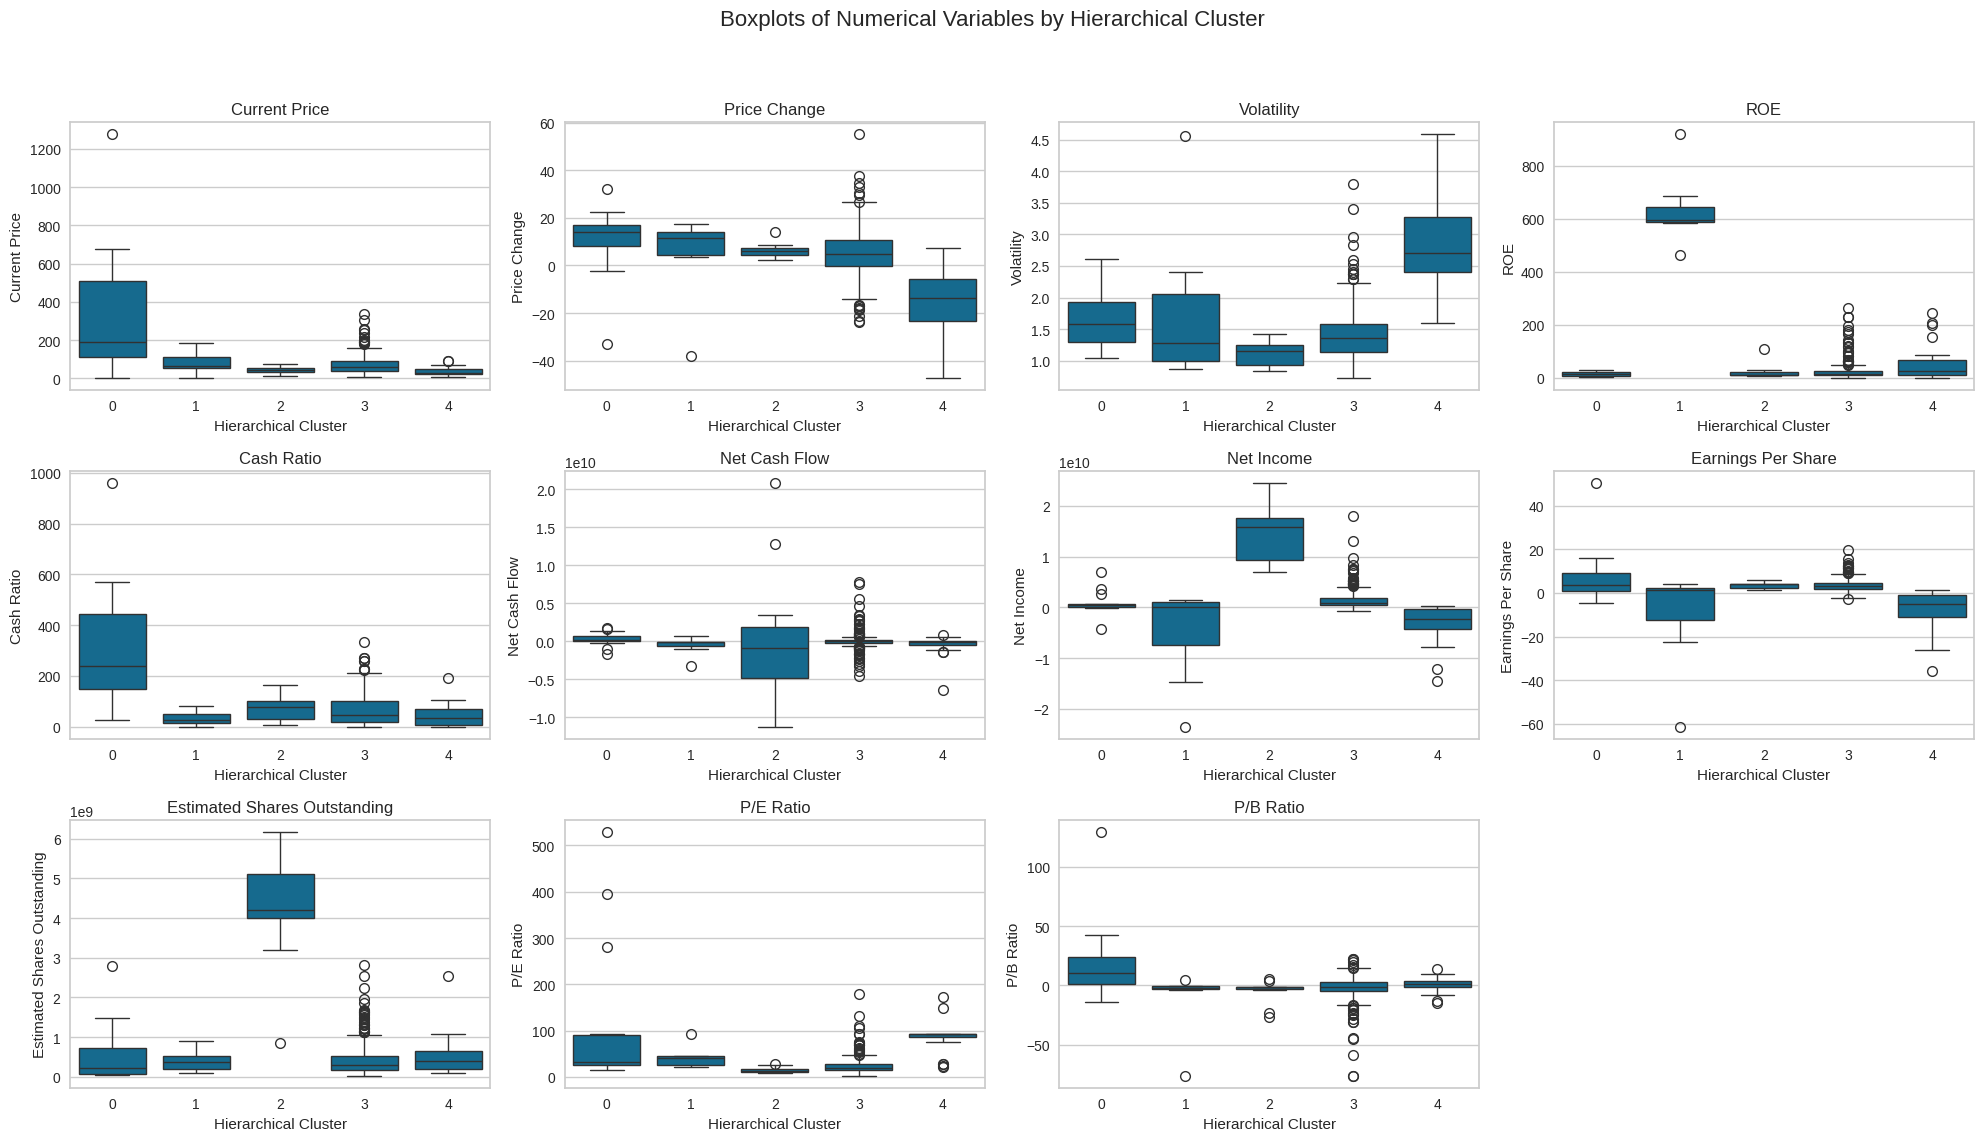

In [ ]:
# Select only the numerical columns from df1_copy, excluding the cluster labels themselves
num_cols_hc = df1_copy.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'HC_segments' in num_cols_hc:
    num_cols_hc.remove('HC_segments')

# Calculate optimal grid size for subplots
num_features_hc = len(num_cols_hc)
num_rows_hc = (num_features_hc + 3) // 4  # +3 for ceiling division to get enough rows for 4 columns
num_cols_grid_hc = 4

plt.figure(figsize=(num_cols_grid_hc * 5, num_rows_hc * 4))
plt.suptitle('Boxplots of Numerical Variables by Hierarchical Cluster', fontsize=16) # Updated title

for i, col in enumerate(num_cols_hc):
    plt.subplot(num_rows_hc, num_cols_grid_hc, i + 1)
    sns.boxplot(x='HC_segments', y=col, data=df1_copy)
    plt.title(f'{col}') # Simpler title as suptitle covers the main theme
    plt.xlabel('Hierarchical Cluster') # Updated label
    plt.ylabel(col)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

### Insights

**Overview:**

*   **Cluster 0** is a small cluster with 15 companies. The stocks have extremely high current prices, volatility, price changes, cash ratio, net cash flow, earnings per share, P/E and P/B ratios.
    * Majority of the companies are in the Health Care and Information Technology sectors.
    * The stocks in this cluster are expensive yet they have a good potential of long term growth. This may appeal more to investors who are interested in long term investments.

*   **Cluster 1** is the smallest (7) stocks with the second highest current price althought it is comparatively far lower than cluster 0. This cluster has the highest ROE and lowest negative net cash flow, net income, earnings per share and P/B ratiio.
    * It appears that the companies may be experiencing challenges that are affecting the value of the stock. The ROE is high hence there is potential for good earnings on the investment.

*   **Cluster 2** is a small cluster with 11 companies. The stocks have moderate values across some of the financial metrics with a negative P/B ratio. These stocks have the highest net cash flow, net income and estimated shares outstanding.
    * This cluster contains more Financial and Telecommunication Services companies.
    * The stocks appear to have moderate value and more stability growth.

*   **Cluster 3** is the largest with 285 companies. It contains majority of the stock with moderate values across some of the financial metrics. The R/B ratio is negative.
    * Majority of the companies are from the Industrials, Financials and Consumer Discretionary sectors.
    * With the largest number of companies, this cluster has the most diversifies investment porfolio with moderate risk and average returns

*   **Cluster 4** has 22 companies with performance. The stocks have a negative price change, net cash flow, net income and earnings per share. They have the highest volatility.
    * 20 of the companies are from the Energy sector.
    * It appears that the stocks may be high risks and less appealing to conservative and low risk investors.

## K-means vs Hierarchical Clustering

* The dataset was not that large however KMeans Clustering took less time of execution than the Hierarchical Clustering. What made the execution of the Hierarchical Clustering longer was generating the dendrogram.

* Both techniques have 5 clusters and have some similarities and differences. In both clusters, there is one large cluster. Cluster 0 in the KMeans and Cluster 3 in the Hierarchical. Both privide a diverse portforlio for Trade & Ahead to consider for their customers. Both techniques have a cluster that has the smallest number of companies, Cluster 2 in the KMeans and Cluster 1 in the Hierarchical. The outputs of both techniques showed good segmentation of the stock market.
2 clusters in KMeans showed less profitable stock. For Hierarchical clustering, one cluster showed less profitable stock.
Based on the insights for both techniques, Heirarchical Clustering seems to have more distinct clusters and comparable values across the given financial metrics.

* There 275 observations in KMeans (Cluster 0) and 285 observations in Hierarchical Clustering (Cluster 3).
There 9 observations in KMeans (Cluster 3) and 11 observations in Hierarchical Clustering (Cluster 2). Both clusters are moderate risk and seem to have stable growth.

* The insights presented for each technique is informative for Trade & Ahead to provide its customers with tailored investment strategies for optimum growth.

## Actionable Insights and Recommendations

- First, it is important for Trade & Ahead to have a detailed database of it's customers. When signing up customer, they must assess their investment goals, risk level and prior knowledge and experience with investment. This will be beneficial in designing effective strategies for optimum growth.

- Based on each client's background information and the results of this current analysis, Trade & Ahead can section their clients into high-, moderate- and low-risk investors.

- Second, they can advise clients not to invest largely in one sector but section so that they can diversify their investment portfolio. Generally, diversification is good in investment and this analysis produced clusters that provide diversified stock. That is cluster 0 in KMeans and cluster 3 in the Hierarchical Clustering.  

- It is important to note that, for a client who is new to investment, diversification may not the best thing to do that the start unless this client has enough funds and is willing to explore the market. For clients who are new to investment and have limited funds, it is important for Trade & Ahead to advise them to prioritize growth before diversification.

- For stability and consistency, their customers can invest in stocks from clusters 0 and 3 in KMeans and clusters 3 and 2 in heirarchical Clustering.

- Trade & Ahead must explain the financial metrics to their clients ensuring that they understand that some stock are high volatile although they have good potential for earnings.

- In addition, they must ensure constant monitoring of the market trends and provide their clients with up-to-date information. Furthermore, Trade & Ahead should explain to their clients the benefits of monitoring the market and when it is optimal to buy and sell stock.

### TO NOTE

Before concluding this work, I attempted to treat the outliers and perform the kmeans and hierarchical clustering.

I treated the outliers by capping and after the clustering, only 3 clusters were found to be optimal.

3 clusters did not seem diverse and ideal hence I went back to perform the analysis without treating the outliers to see the difference (5 clusters were formed).

I decided to stick to keeping the outliers for the analysis to have more diverse and indepth details.